In [1]:
import polars as pl
import numpy as np

In [2]:
from matplotlib import pyplot as plt

In [3]:
df = pl.read_csv("../data/stockdata3.csv")

In [4]:
stocks = [c for c in df.columns if c != "day" and c != "timestr"]
returns = [f"r{s}" for s in stocks]

In [5]:
INTRA = 0
EXTRA = 1
CLOSE = 2


def get_ret(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .select(
            [
                pl.col("day"),
                pl.col("datetime"),
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
            ]
        )
        .with_columns(
            [
                pl.when(pl.col("day").diff() == 0)
                .then(pl.lit(INTRA))
                .otherwise(pl.lit(EXTRA))
                .alias("return_type")
            ]
        )
    )


def get_ret_cc(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .group_by("day")
        .agg([pl.col(s).drop_nulls().last()])
        .sort("day")  # must sort before shift(1), group_by output is unordered
        .with_columns(
            [
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
                pl.lit(CLOSE).alias("return_type"),
            ]
        )
    )


def get_ret_all(df, s):
    ret = get_ret(df, s[0])
    for stock in s[1:]:
        print(stock)
        ret = ret.join(get_ret(df, stock), on="datetime", how="inner")

    return ret


# def add_ret(df):
#     return (
#         df.sort("datetime")
#         .fill_nan(None)
#         .with_columns(
#             [
#                 ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}")
#                 for s in stocks
#             ]
#         )
#         .with_columns(
#             [
#                 pl.when(pl.col("day").diff() == 0)
#                 .then(pl.lit(INTRA))
#                 .otherwise(pl.lit(EXTRA))
#                 .alias("return_type")
#             ]
#         )
#     )

In [6]:
def daily_vol_from_ret(df, returns):
    if isinstance(returns, str):
        return df.group_by("day").agg(pl.col(returns).pow(2).sum().sqrt())
    else:
        return df.group_by("day").agg(
            [
                (pl.col(s1) * pl.col(s2)).sum().sqrt().alias(f"")
                for s1 in returns
                for s2 in returns
            ]
        )


def daily_vol(df, stocks, return_type=None):

    mask = (
        pl.col("return_type") == return_type
        if return_type is not None
        else pl.lit(True)
    )
    if isinstance(stocks, str):
        stocks = [stocks]
    returns = [f"r{s}" for s in stocks]
    vols = daily_vol_from_ret(get_ret(df, stocks[0]).filter(mask), returns[0])
    for s, r in zip(stocks[1:], returns[1:]):
        vols = vols.join(daily_vol_from_ret(get_ret(df, s).filter(mask), r), on="day")
    return vols


def combine_intraday_gap_vol(intraday_vols, gap_vols, returns, day_col="day"):
    """Combine intraday RV and overnight gap RV on the daily-vol scale."""
    joined = intraday_vols.join(
        gap_vols.select(day_col, *returns), on=day_col, how="left", suffix="_gap"
    )
    return joined.with_columns(
        [
            (pl.col(r).pow(2) + pl.col(f"{r}_gap").fill_null(0).pow(2)).sqrt().alias(r)
            for r in returns
        ]
    ).select(day_col, *returns)

In [7]:
# deal with c: likely split
def normalize_c(df):
    idxs = df.filter(pl.col("c").diff().abs() > 0.4 * pl.col("c"))["index"]
    if len(idxs) > 0:
        index = idxs[0]
    else:
        return df
    print(index)
    return df.with_columns(
        pl.when(pl.col("index") < index)
        .then(pl.col("c") / 2)
        .otherwise(pl.col("c"))
        .alias("c")
    )

In [8]:
# deal with c: likely split
# deal with c: likely split
def mask_micro_noise(col, thd=100, neighbor=1):
    ratio = thd / 1e4  # bps
    ret = (pl.col(col) / pl.col(col).shift(1)).log()
    mask = pl.lit(False)
    for n in range(1, neighbor + 1):
        mask |= (
            (ret * ret.shift(-n) < 0)
            & (ret.abs() > ratio)
            & (ret.shift(-n).abs() > ratio)
        )
    return mask


def mask_denoised(col, thd=100, neighbor=1):
    return ~mask_micro_noise(col, thd, neighbor)


# def clean_d(df):
#     return df

In [9]:
def downsample(df, freq, keep_open=True):
    sample_time = "__sample_datetime"
    sampled = (
        df.with_columns(pl.col("datetime").alias(sample_time))
        .group_by_dynamic("datetime", every=freq, group_by="day")
        .agg(
            pl.exclude(["day", "datetime", sample_time]).last(),
            pl.col(sample_time).last(),
        )
        .drop("datetime")
        .rename({sample_time: "datetime"})
    )
    if keep_open:
        opens = df.sort("datetime").group_by("day", maintain_order=True).head(1)
        sampled = pl.concat([opens, sampled], how="diagonal_relaxed").unique(
            ["day", "datetime"], keep="first"
        )
    return sampled.sort(["day", "datetime"])

## load data

In [10]:
df = (
    df.with_columns(
        (pl.date(2000, 1, 1) + pl.duration(days=pl.col("day") - 1))
        .dt.combine(pl.col("timestr").str.to_time("%H:%M:%S"))
        .alias("datetime")
    )
    if "datetime" not in df.columns
    else df
)
display(df.select("day", "timestr", "datetime"))
df = df.with_row_index() if "index" not in df.columns else df

day,timestr,datetime
i64,str,datetime[μs]
1,"""09:30:00""",2000-01-01 09:30:00
1,"""09:31:00""",2000-01-01 09:31:00
1,"""09:32:00""",2000-01-01 09:32:00
1,"""09:33:00""",2000-01-01 09:33:00
1,"""09:34:00""",2000-01-01 09:34:00
…,…,…
362,"""15:56:00""",2000-12-27 15:56:00
362,"""15:57:00""",2000-12-27 15:57:00
362,"""15:58:00""",2000-12-27 15:58:00


In [11]:
# clean a and d
df = df.with_columns(
    pl.when(pl.col("a") == 0).then(None).otherwise(pl.col("a")).alias("a"),
    pl.when(pl.col("d") == 1).then(None).otherwise(pl.col("d")).alias("d"),
)
# clean c
df = normalize_c(df)
# filter d
NOISE_THD = 100  # 100 bps
# df = df.filter(mask_denoised("d", NOISE_THD))

39882


In [12]:
# categories:
stocks_normal = ["a", "c", "e"]  # leave it as is
stocks_downsample_5min_denoise = ["d"]  # down sample to 5min
stocks_downsample_120min = ["b"]  # down sample to 120min
stocks_jump = ["f"]  # special treat, do Poisson jump or monthly close-close volatility

In [13]:
display(downsample(df, "10m"))

day,index,timestr,a,b,c,d,e,f,datetime
i64,u32,str,f64,f64,f64,f64,f64,f64,datetime[μs]
1,0,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,9,"""09:39:00""",326.225,14.055,47.2875,50.06,49.95,17.025,2000-01-01 09:39:00
1,19,"""09:49:00""",327.765,13.905,47.3325,50.245,49.89,17.025,2000-01-01 09:49:00
1,29,"""09:59:00""",327.43,13.875,47.3175,50.275,49.98,17.025,2000-01-01 09:59:00
1,39,"""10:09:00""",328.165,14.005,47.25,50.245,49.88,17.025,2000-01-01 10:09:00
…,…,…,…,…,…,…,…,…,…
362,98320,"""15:29:00""",405.03,5.625,45.417,45.855,43.47,10.745,2000-12-27 15:29:00
362,98330,"""15:39:00""",404.94,5.515,45.405,45.845,43.66,10.745,2000-12-27 15:39:00
362,98340,"""15:49:00""",404.735,5.615,45.395,45.845,43.64,10.745,2000-12-27 15:49:00


In [14]:
df

index,day,timestr,a,b,c,d,e,f,datetime
u32,i64,str,f64,f64,f64,f64,f64,f64,datetime[μs]
0,1,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,1,"""09:31:00""",325.245,13.89,47.2575,49.99,49.96,17.025,2000-01-01 09:31:00
2,1,"""09:32:00""",325.58,13.905,47.2825,49.995,49.96,17.025,2000-01-01 09:32:00
3,1,"""09:33:00""",325.47,13.955,47.3225,50.065,49.92,17.025,2000-01-01 09:33:00
4,1,"""09:34:00""",325.295,13.975,47.29,50.03,49.9,17.025,2000-01-01 09:34:00
…,…,…,…,…,…,…,…,…,…
98347,362,"""15:56:00""",404.825,5.515,45.352,45.305,43.57,10.745,2000-12-27 15:56:00
98348,362,"""15:57:00""",404.815,5.615,45.362,45.795,43.61,10.745,2000-12-27 15:57:00
98349,362,"""15:58:00""",404.915,5.625,45.352,45.805,43.63,10.755,2000-12-27 15:58:00


In [15]:
vols = daily_vol(df, stocks_normal + stocks_jump, return_type=INTRA)
vols = vols.join(
    daily_vol(
        downsample(df.filter(mask_denoised("d", NOISE_THD)), "5m"),
        stocks_downsample_5min_denoise,
        return_type=INTRA,
    ),
    on="day",
)
vols = vols.join(
    daily_vol(downsample(df, "120m"), stocks_downsample_120min, return_type=INTRA),
    on="day",
)

vols_intraday = vols.sort("day")
vols_gap = daily_vol(df, stocks, return_type=EXTRA).sort("day")
vols = combine_intraday_gap_vol(vols_intraday, vols_gap, returns).sort("day")

# close-to-close daily returns, one row per day --- join on day (not concat:
# each get_ret_cc frame is 1-row-per-day, a horizontal concat would misalign).
ret_cc = get_ret_cc(df, stocks[0]).select("day", f"r{stocks[0]}")
for s in stocks[1:]:
    ret_cc = ret_cc.join(get_ret_cc(df, s).select("day", f"r{s}"), on="day")
ret_cc = ret_cc.sort("day")

In [16]:
ret_cc

day,ra,rb,rc,rd,re,rf
i64,f64,f64,f64,f64,f64,f64
1,null,null,null,null,null,null
2,47.502434,112.558346,-51.1156,-24.021631,229.207842,5.787037
3,80.120082,173.374662,89.281562,63.929895,-89.065408,402.548682
4,-7.3389,-117.567053,-101.566904,548.645262,-140.142434,121.514889
5,73.89141,-48.814602,21.356121,-642.68357,10.075568,0.0
…,…,…,…,…,…,…
355,120.100965,236.805237,48.244183,132.928521,-43.134503,-18.340216
359,80.995097,-54.151757,-71.798751,8.655199,121.734407,0.0
360,-97.124132,-539.164031,-241.779733,-170.142615,206.628624,-326.521545


In [17]:
# vols_bm = daily_vol(df, stocks_normal + stocks_jump)
# vols_bm = vols_bm.join(daily_vol(df, stocks_downsample), on="day")

In [18]:
vols = vols.sort("day")
# vols_bm = vols_bm.sort("day")

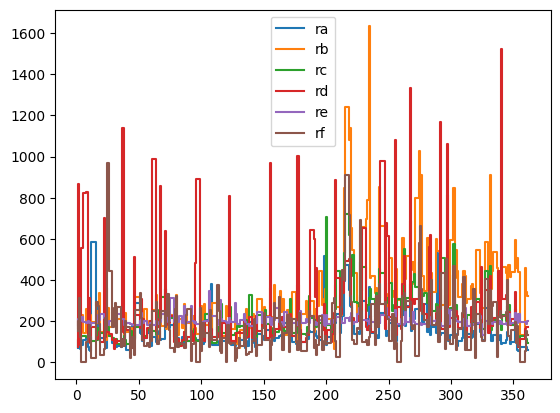

In [19]:
for v in returns:
    # print(f"=============={v}==============")
    plt.step(vols["day"], vols[v], label=v)
    # plt.plot(vols_bm[v])
plt.legend()
plt.show()

## Check autocorrelation

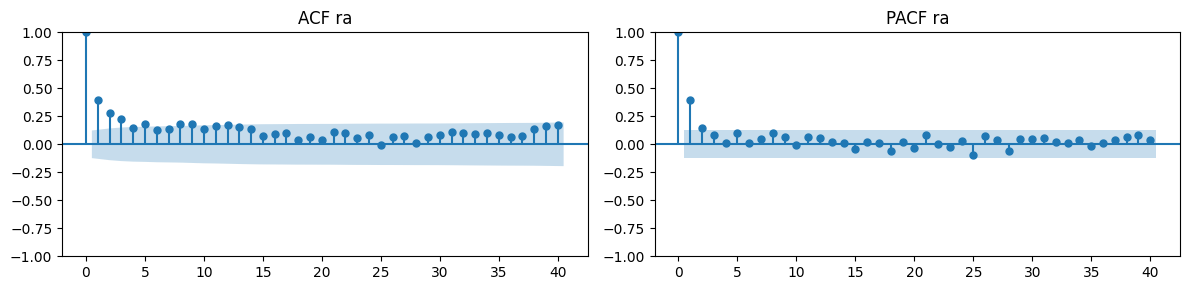

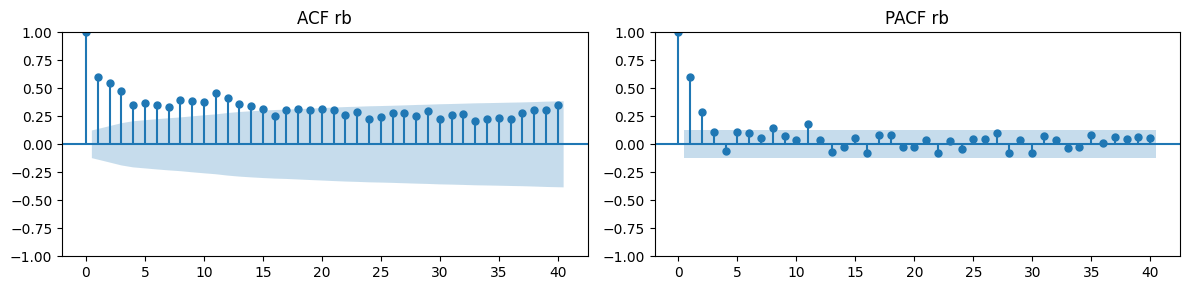

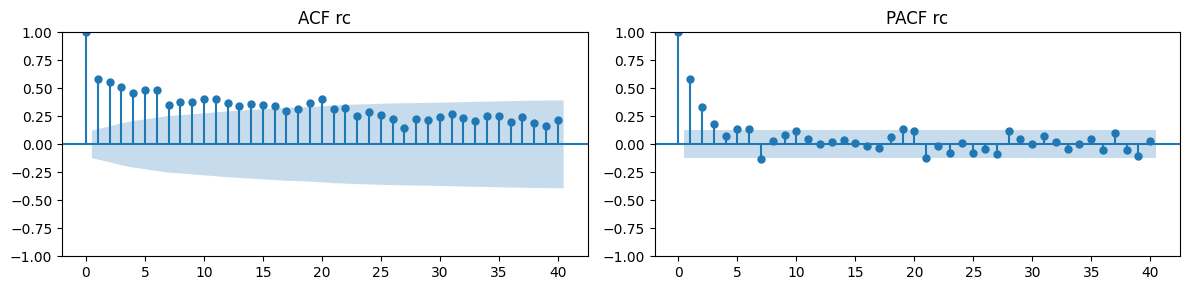

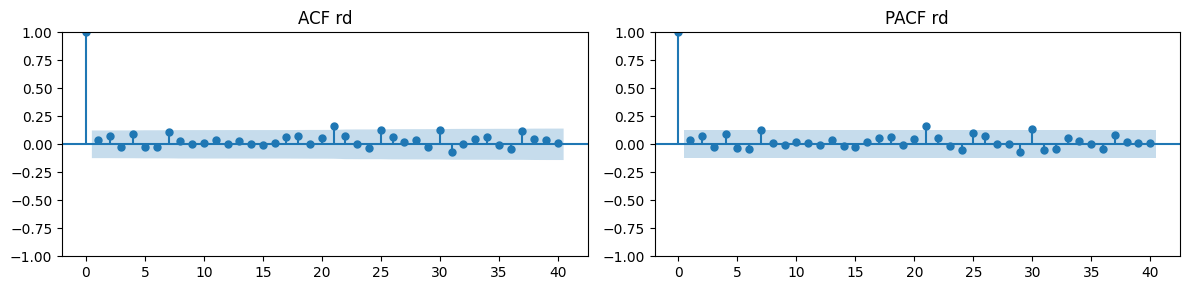

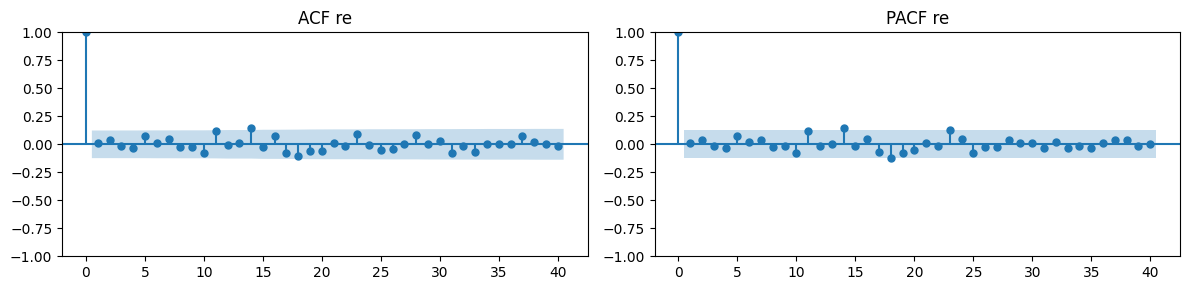

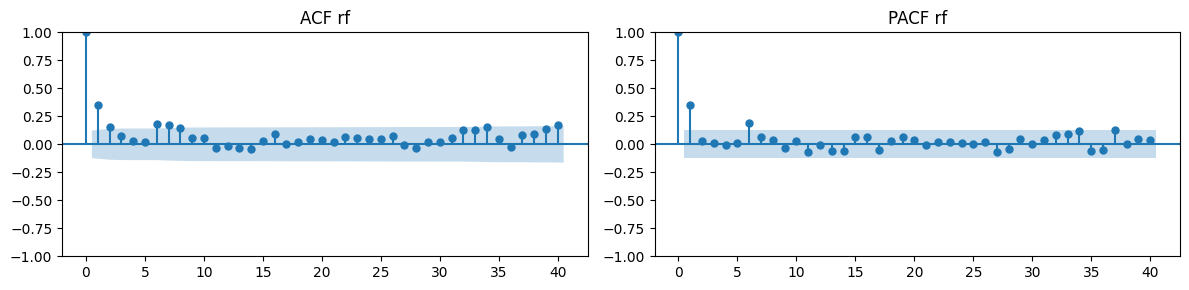

In [20]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acfs, pacfs = {}, {}
for r in returns:
    data = vols[r].drop_nulls().to_numpy()
    acfs[r] = acf(data, nlags=40, alpha=0.05)
    pacfs[r] = pacf(data, nlags=40, alpha=0.05)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(data, lags=40, alpha=0.05, ax=ax1)
    plot_pacf(data, lags=40, alpha=0.05, ax=ax2)
    ax1.set_title(f"ACF {r}")
    ax2.set_title(f"PACF {r}")
    plt.tight_layout()
    plt.show()

## Check daily volatilities

=====================ra=====================
150.59140903673523 81.69682269794482


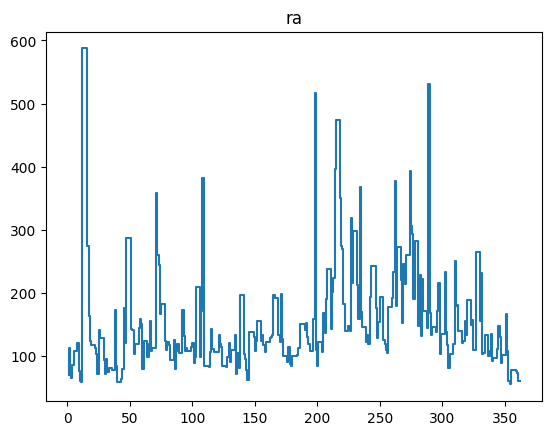

=====================rb=====================
330.35054156766813 210.7752545281232


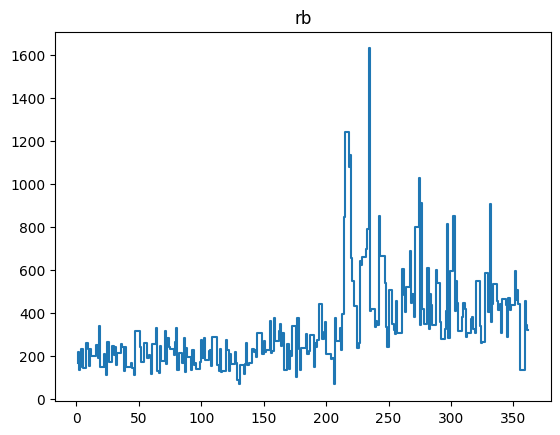

=====================rc=====================
219.5033697875619 113.08198950608919


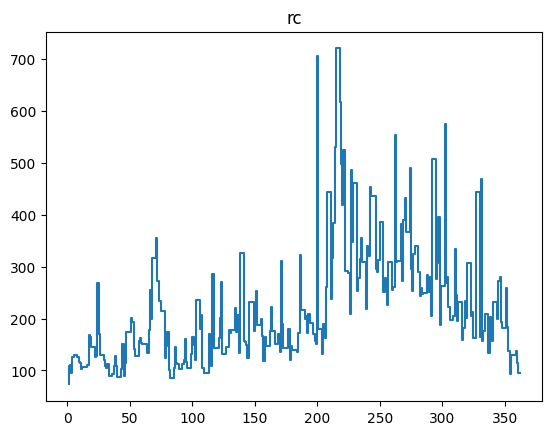

=====================rd=====================
271.3593070811964 239.23637208568462


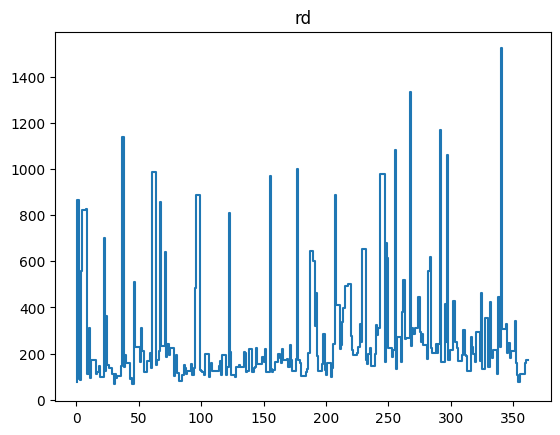

=====================re=====================
204.98202197859922 25.802601505245352


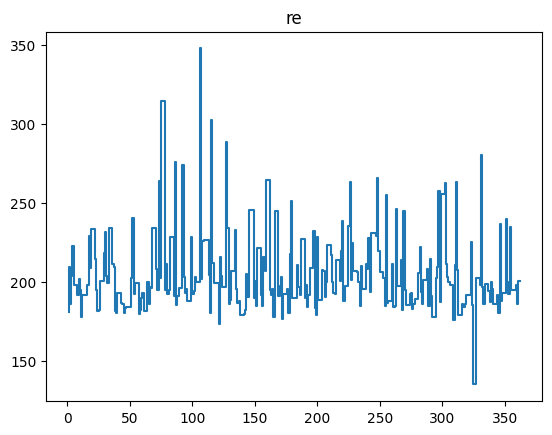

=====================rf=====================
182.44564461547728 139.19029561387677


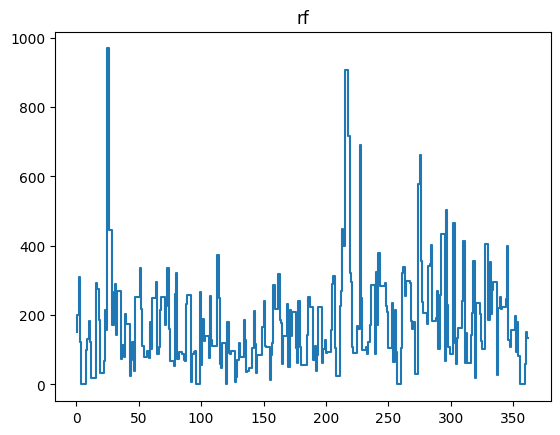

In [21]:
for r in returns:
    print(f"====================={r}=====================")
    print(vols[r].mean(), vols[r].std())
    plt.step(vols["day"], vols[r])
    plt.title(r)
    plt.show()

## Check the short day

In [22]:
print(vols.filter(pl.col("day") == 327))
print(vols.mean())

shape: (1, 7)
┌─────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ day ┆ ra         ┆ rb         ┆ rc         ┆ rd         ┆ re         ┆ rf         │
│ --- ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ i64 ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 327 ┆ 108.801632 ┆ 262.896084 ┆ 161.840405 ┆ 131.695627 ┆ 134.897438 ┆ 101.885751 │
└─────┴────────────┴────────────┴────────────┴────────────┴────────────┴────────────┘
shape: (1, 7)
┌────────────┬────────────┬────────────┬───────────┬────────────┬────────────┬────────────┐
│ day        ┆ ra         ┆ rb         ┆ rc        ┆ rd         ┆ re         ┆ rf         │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---        ┆ ---        ┆ ---        │
│ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64        ┆ f64        ┆ f64        │
╞═

In [23]:
np.sqrt(391 / 211)

np.float64(1.3612790194226823)

## Check lagged cross correlation

In [24]:
for lag in [1, 5, 10, 21, 42, 63]:
    lagged = (
        vols.select(returns).shift(lag).rename({c: f"{c}_lag{lag}" for c in returns})
    )
    combined = pl.concat([vols.select(returns), lagged], how="horizontal").drop_nulls()
    corr = combined.corr()
    n = len(returns)
    block = corr[:n, n:]
    block = block.rename({f"{c}_lag{lag}": c for c in returns})
    block = block.insert_column(0, pl.Series("name", returns))
    print(f"\ncorr(RV_i(t), RV_j(t-{lag})):")
    print(block)


corr(RV_i(t), RV_j(t-1)):
shape: (6, 7)
┌──────┬──────────┬──────────┬──────────┬───────────┬───────────┬──────────┐
│ name ┆ ra       ┆ rb       ┆ rc       ┆ rd        ┆ re        ┆ rf       │
│ ---  ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---      │
│ str  ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64       ┆ f64      │
╞══════╪══════════╪══════════╪══════════╪═══════════╪═══════════╪══════════╡
│ ra   ┆ 0.400665 ┆ 0.366118 ┆ 0.396261 ┆ 0.062991  ┆ -0.018004 ┆ 0.241319 │
│ rb   ┆ 0.412196 ┆ 0.603098 ┆ 0.539187 ┆ 0.115898  ┆ -0.029343 ┆ 0.329818 │
│ rc   ┆ 0.399748 ┆ 0.527279 ┆ 0.584332 ┆ 0.187095  ┆ 0.015531  ┆ 0.31658  │
│ rd   ┆ 0.065285 ┆ 0.115037 ┆ 0.146636 ┆ 0.037918  ┆ -0.033276 ┆ 0.098126 │
│ re   ┆ 0.066547 ┆ 0.034437 ┆ 0.062487 ┆ -0.102969 ┆ 0.010907  ┆ 0.097417 │
│ rf   ┆ 0.292381 ┆ 0.30767  ┆ 0.303719 ┆ 0.147586  ┆ -0.057058 ┆ 0.353969 │
└──────┴──────────┴──────────┴──────────┴───────────┴───────────┴──────────┘

corr(RV_i(t), RV_j(t-5)):
shape: (

## Model fitting/prediction

In [25]:
from collections.abc import Callable, Sequence


# ---- pooling: aggregate the daily-RV expr over a window of w trading days ----
# Daily RV is itself sqrt(daily variance); the choice is how those vols compose.
def pool_mean(e: pl.Expr, w: int) -> pl.Expr:
    """Plain average of daily RV over w days --- the literal Corsi HAR pooling."""
    return e.rolling_mean(w)


def pool_rms(e: pl.Expr, w: int) -> pl.Expr:
    """RMS of daily RV over w days: sqrt(mean RV^2). Dimensionally consistent
    (variances are additive, vols are not); stays on the daily-vol scale."""
    return e.pow(2).rolling_mean(w).sqrt()


# ---- feature builders: act on the daily-RV expr, return a causal (info<=t) expr ----
def ewma(half_life: float, on_variance: bool = False):
    """Exponentially weighted moving avg of daily RV, info up to row t (causal).

    A self-contained causal feature --- pass it in `feature_fns`.
    half_life : decay in trading days. RiskMetrics lambda=0.94 ~= half_life 11.
    on_variance : if True, EWMA the variance (RV^2) RiskMetrics-style and sqrt
                  back; if False, EWMA the vol series directly.
    """

    def fn(e: pl.Expr) -> pl.Expr:
        if on_variance:
            return e.pow(2).ewm_mean(half_life=half_life, adjust=False).sqrt()
        return e.ewm_mean(half_life=half_life, adjust=False)

    return fn


def make_features_targets(
    vols: pl.DataFrame,
    cols: Sequence[str],
    windows: Sequence[int] = (1, 5, 10, 21, 42, 63),
    horizon: int = 21,
    pool: Callable[[pl.Expr, int], pl.Expr] = pool_rms,
    feature_fns: dict[str, Callable[[pl.Expr], pl.Expr]] | None = None,
    target_fn: Callable[[pl.Expr], pl.Expr] | None = None,
    day_col: str = "day",
    drop_nulls: bool = False,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Turn a daily realized-vol frame into (features, target) frames.

    `vols` has one row per trading day plus `day_col`. Rows are assumed to be
    consecutive trading days, so a window / horizon of N rows == N trading days.
    All features use info up to and including day t; the target is strictly
    forward (t+1..t+h), so there is no overlap and no leakage. For row t:
      HAR feature {c}_avg{w} = pool of daily RV over the trailing w days [t-w+1..t]
      extra       {c}{name}  = feature_fns[name](col c)   (causal)
      target      {c}_fwd    = pool of daily RV over the forward h days [t+1..t+h]

    windows : HAR averaging windows in trading days. (1,5,21) are the classic
              daily / weekly / monthly HAR-RV components (Corsi 2009 uses 22).
              w=1 is RV(t) itself and keeps the bare name {c}.
    horizon : 21 is the usual "1 month" (252 trading days / 12 ~= 21); Corsi's
              HAR-RV uses 22; 20 is just a round "4 weeks". Default 21.
    pool    : (expr, w)->expr aggregator used for BOTH the HAR features and the
              default target, so the two always share one convention. pool_rms
              (default) is dimensionally consistent; pool_mean is literal Corsi.
    feature_fns : optional {name: fn(expr)->expr} extra causal features, e.g.
              {"_ewma11": ewma(11)}. Applied per column, info up to t.
    target_fn : optional override of the forward target. Default is
              pool(., horizon) shifted back h rows. Must be forward-looking.
    drop_nulls : if False (default) keep every row from day 1 --- partial
              windows (head) and missing forward targets (tail) stay null, so
              you can experiment with models that don't need a full HAR window.
              Set True for a ready-to-fit frame with the head/tail trimmed.

    Returns (X, y), both keyed by `day_col` and row-aligned.
    """
    vols = vols.sort(day_col)
    target_fn = target_fn or (lambda e: pool(e, horizon).shift(-horizon))

    feature_exprs = [
        pool(pl.col(c), w).alias(f"{c}" + (f"_avg{w}" if w != 1 else ""))
        for c in cols
        for w in windows
    ]
    if feature_fns:
        feature_exprs += [
            fn(pl.col(c)).alias(f"{c}{name}")
            for name, fn in feature_fns.items()
            for c in cols
        ]
    target_exprs = [target_fn(pl.col(c)).alias(f"{c}_fwd") for c in cols]

    combined = vols.select(pl.col(day_col), *feature_exprs, *target_exprs)
    if drop_nulls:
        combined = combined.drop_nulls()  # trims the window head + horizon tail

    feat_names = [e.meta.output_name() for e in feature_exprs]
    tgt_names = [e.meta.output_name() for e in target_exprs]
    return combined.select(day_col, *feat_names), combined.select(day_col, *tgt_names)

In [48]:
windows = [1, 5, 10, 21, 42, 63]
X, y = make_features_targets(
    vols,
    returns,
    # 5 trading days ~= one week; 10/15 are two-/three-week windows.
    windows=windows,
    horizon=21,
    pool=pool_rms,  # pool_mean for the literal Corsi HAR average
    feature_fns={
        # "_ewma1": ewma(1),
        # "_ewma5": ewma(5),
        # "_ewma10": ewma(10),
        # # "_ewma11": ewma(11),
        # # "_ewma15": ewma(15),
        # "_ewma21": ewma(21),
        # "_ewma44": ewma(44),
        # "_ewma63": ewma(44),
        f"_ewma{i}": ewma(i) for i in windows
    },
)
print("X:", X.shape, " y:", y.shape)
display(X.head())
display(y.head())

X: (252, 73)  y: (252, 7)


day,ra,ra_avg5,ra_avg10,ra_avg21,ra_avg42,ra_avg63,rb,rb_avg5,rb_avg10,rb_avg21,rb_avg42,rb_avg63,rc,rc_avg5,rc_avg10,rc_avg21,rc_avg42,rc_avg63,rd,rd_avg5,rd_avg10,rd_avg21,rd_avg42,rd_avg63,re,re_avg5,re_avg10,re_avg21,re_avg42,re_avg63,rf,rf_avg5,rf_avg10,rf_avg21,rf_avg42,rf_avg63,ra_ewma1,rb_ewma1,rc_ewma1,rd_ewma1,re_ewma1,rf_ewma1,ra_ewma5,rb_ewma5,rc_ewma5,rd_ewma5,re_ewma5,rf_ewma5,ra_ewma10,rb_ewma10,rc_ewma10,rd_ewma10,re_ewma10,rf_ewma10,ra_ewma21,rb_ewma21,rc_ewma21,rd_ewma21,re_ewma21,rf_ewma21,ra_ewma42,rb_ewma42,rc_ewma42,rd_ewma42,re_ewma42,rf_ewma42,ra_ewma63,rb_ewma63,rc_ewma63,rd_ewma63,re_ewma63,rf_ewma63
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,69.488817,null,null,null,null,null,168.132493,null,null,null,null,null,72.913447,null,null,null,null,null,77.567307,null,null,null,null,null,181.036022,null,null,null,null,null,151.672655,null,null,null,null,null,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655
2,111.775185,null,null,null,null,null,218.123146,null,null,null,null,null,108.681168,null,null,null,null,null,864.922088,null,null,null,null,null,209.161885,null,null,null,null,null,199.088268,null,null,null,null,null,90.632001,193.12782,90.797308,471.244697,195.098954,175.380462,74.962764,174.603755,77.543559,179.48994,184.676899,157.81058,72.320609,171.480218,75.308705,130.294101,182.919527,154.847937,70.86178,169.755601,74.074762,103.131317,181.949219,153.212156,70.180963,168.950744,73.498896,90.454783,181.496388,152.448757,69.951516,168.679492,73.304819,86.182568,181.343776,152.191478
3,80.045161,null,null,null,null,null,135.390345,null,null,null,null,null,111.112787,null,null,null,null,null,91.455155,null,null,null,null,null,185.999108,null,null,null,null,null,310.956068,null,null,null,null,null,85.338581,164.259082,100.955048,281.349926,190.549031,243.168265,75.620677,169.527601,81.889076,168.093887,184.848058,177.635177,72.837899,169.063387,77.706397,127.693173,183.125757,165.302031,71.159948,168.639822,75.277321,102.752212,182.080712,158.33382,70.342421,168.401425,74.114563,90.471158,181.570089,155.043215,70.061961,168.315242,73.718515,86.240261,181.394715,153.928686
4,64.058028,null,null,null,null,null,147.772099,null,null,null,null,null,94.823558,null,null,null,null,null,86.242308,null,null,null,null,null,203.283924,null,null,null,null,null,122.526099,null,null,null,null,null,74.698305,156.015591,97.889303,183.796117,196.916477,182.847182,74.123899,166.711364,83.563438,157.498246,187.234571,170.501338,72.249937,167.637573,78.852682,124.917333,184.47569,162.437455,70.929362,167.962284,75.911952,102.216165,182.769142,157.171207,70.239558,168.063762,74.453529,90.40194,181.925503,154.510973,69.996266,168.090458,73.949447,86.240284,181.634227,153.585077
5,84.972605,83.729792,null,null,null,null,229.613169,183.703886,null,null,null,null,126.818183,104.449392,null,null,null,null,556.814119,464.747383,null,null,null,null,222.856603,201.051149,null,null,null,null,0.0,186.733529,null,null,null,null,79.835455,192.81438,112.353743,370.305118,209.88654,91.423591,75.528258,174.853967,89.16274,209.189461,191.845823,148.430035,73.101936,171.787893,82.064788,153.840169,187.045944,151.559505,71.385321,169.963979,77.564787,116.976152,184.070711,152.068137,70.480709,169.071207,75.310637,98.036206,182.595466,151.981927,70.160137,168.763641,74.527938,91.389317,182.085284,151.904545


day,ra_fwd,rb_fwd,rc_fwd,rd_fwd,re_fwd,rf_fwd
i64,f64,f64,f64,f64,f64,f64
1,172.319532,208.017211,137.146248,398.882935,203.821784,287.506833
2,171.848577,209.270851,137.005922,352.247806,203.538361,291.189958
3,171.735046,210.018297,137.049587,352.290395,204.138368,284.886688
4,172.076696,212.676295,136.878402,352.517371,205.687959,289.713402
5,171.907254,213.997263,135.568255,332.465849,205.102039,290.163714


### PCA diagnostic on the pre-modeling feature matrix

This checks the standardized HAR/EWMA feature matrix immediately after `X, y` are built, before adding the GARCH benchmark or any model-specific transforms.

component,explained_variance,explained_variance_ratio,cumulative_ratio
str,f64,f64,f64
"""PC1""",43.006812,0.594173,0.594173
"""PC2""",7.783484,0.107535,0.701708
"""PC3""",5.966764,0.082436,0.784144
"""PC4""",2.883594,0.039839,0.823983
"""PC5""",2.242944,0.030988,0.854971
"""PC6""",1.658494,0.022913,0.877884
"""PC7""",1.472831,0.020348,0.898232
"""PC8""",1.037043,0.014328,0.91256
"""PC9""",0.951098,0.01314,0.9257


feature,PC1,PC2,PC3,PC4,PC5,max_abs_loading
str,f64,f64,f64,f64,f64,f64
"""rd_ewma1""",0.071204,0.030189,-0.060724,0.4504,-0.073093,0.4504
"""rd_avg5""",0.069593,-0.000291,-0.026932,0.434814,-0.062618,0.434814
"""rd""",0.044084,0.029865,-0.048351,0.389262,-0.078525,0.389262
"""re_ewma42""",0.104678,0.007208,0.114678,0.069253,0.350096,0.350096
"""re_avg63""",-0.075643,0.048947,0.117165,0.100289,0.348582,0.348582
…,…,…,…,…,…,…
"""re_ewma21""",-0.018749,0.187363,0.295851,0.060139,0.257792,0.295851
"""re_avg10""",-0.022109,0.168215,0.292715,-0.012348,-0.119047,0.292715
"""re""",-0.000318,0.114954,0.151314,0.07635,-0.290444,0.290444


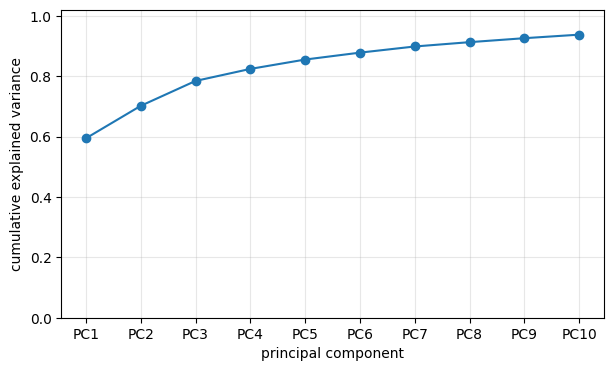

In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# pca_feature_cols = [c for c in X.columns if c != "day"]
pca_feature_cols = [
    c
    for c in X.columns
    if c != "day"
    # and c.startswith("log_")
    # and (
    #     c.endswith("_ewma21")
    #     #  or c.endswith("_ewma11") or c.endswith("_ewma21")
    # )
]
# print(pca_feature_cols)
X_pca = X.select(["day", *pca_feature_cols]).drop_nulls().drop_nans()
# display(X_pca)
X_pca_scaled = StandardScaler().fit_transform(X_pca.select(pca_feature_cols).to_numpy())

pca = PCA()
pca_scores = pca.fit_transform(X_pca_scaled)
pca_summary = pl.DataFrame(
    {
        "component": [f"PC{i + 1}" for i in range(len(pca.explained_variance_ratio_))],
        "explained_variance": pca.explained_variance_,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
    }
)
display(pca_summary.head(10))

n_loading_components = min(5, len(pca_feature_cols))
loading_cols = [f"PC{i + 1}" for i in range(n_loading_components)]
pca_loadings = pl.DataFrame(
    {
        "feature": pca_feature_cols,
        **{f"PC{i + 1}": pca.components_[i] for i in range(n_loading_components)},
    }
)
display(
    pca_loadings.with_columns(
        pl.max_horizontal([pl.col(c).abs() for c in loading_cols]).alias(
            "max_abs_loading"
        )
    )
    .sort("max_abs_loading", descending=True)
    .head(15)
)

plt.figure(figsize=(7, 4))
plt.plot(
    pca_summary["component"][:10],
    pca_summary["cumulative_ratio"][:10],
    marker="o",
)
plt.ylim(0, 1.02)
plt.ylabel("cumulative explained variance")
plt.xlabel("principal component")
plt.grid(alpha=0.3)
plt.show()

In [51]:
for r in reversed(pca_loadings.sort("PC1").rows()):
    print(r[0], r[1])

rc_ewma21 0.14933916318831603
ra_ewma21 0.14856948277809798
rb_ewma10 0.14813089353787573
rc_avg63 0.14732494279388186
rf_ewma10 0.1468742044565676
rc_avg42 0.14651844467380667
rb_avg42 0.14563514514255044
rc_ewma10 0.14521004277052038
ra_ewma42 0.14502265614237428
rf_avg42 0.14456399820756163
rb_ewma21 0.1444179692293821
rb_ewma5 0.14441065195710698
rf_ewma21 0.14390555792196003
rb_avg63 0.14322155732027275
rc_ewma42 0.14318693790607664
rd_ewma21 0.14276127779914388
rd_ewma10 0.1409793953180042
ra_avg63 0.14078019412802784
ra_ewma63 0.14024066030046298
rb_avg21 0.13991869470494425
ra_avg42 0.139867007537021
ra_ewma10 0.13853025137324002
rc_ewma63 0.13841387282994533
rc_avg21 0.13671190247574272
rd_ewma42 0.13640635430848883
rf_ewma5 0.13557512009642245
rb_ewma42 0.13532204783332666
rc_ewma5 0.13472944515844704
rb_avg10 0.13443572806598986
rf_avg21 0.13383614899346474
rd_ewma63 0.13245664550705855
rd_avg42 0.1317423858895871
rf_ewma42 0.13173689672778197
rf_avg63 0.13151771984429023
rb

In [52]:
X.sort("day")

day,ra,ra_avg5,ra_avg10,ra_avg21,ra_avg42,ra_avg63,rb,rb_avg5,rb_avg10,rb_avg21,rb_avg42,rb_avg63,rc,rc_avg5,rc_avg10,rc_avg21,rc_avg42,rc_avg63,rd,rd_avg5,rd_avg10,rd_avg21,rd_avg42,rd_avg63,re,re_avg5,re_avg10,re_avg21,re_avg42,re_avg63,rf,rf_avg5,rf_avg10,rf_avg21,rf_avg42,rf_avg63,ra_ewma1,rb_ewma1,rc_ewma1,rd_ewma1,re_ewma1,rf_ewma1,ra_ewma5,rb_ewma5,rc_ewma5,rd_ewma5,re_ewma5,rf_ewma5,ra_ewma10,rb_ewma10,rc_ewma10,rd_ewma10,re_ewma10,rf_ewma10,ra_ewma21,rb_ewma21,rc_ewma21,rd_ewma21,re_ewma21,rf_ewma21,ra_ewma42,rb_ewma42,rc_ewma42,rd_ewma42,re_ewma42,rf_ewma42,ra_ewma63,rb_ewma63,rc_ewma63,rd_ewma63,re_ewma63,rf_ewma63
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,69.488817,null,null,null,null,null,168.132493,null,null,null,null,null,72.913447,null,null,null,null,null,77.567307,null,null,null,null,null,181.036022,null,null,null,null,null,151.672655,null,null,null,null,null,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655,69.488817,168.132493,72.913447,77.567307,181.036022,151.672655
2,111.775185,null,null,null,null,null,218.123146,null,null,null,null,null,108.681168,null,null,null,null,null,864.922088,null,null,null,null,null,209.161885,null,null,null,null,null,199.088268,null,null,null,null,null,90.632001,193.12782,90.797308,471.244697,195.098954,175.380462,74.962764,174.603755,77.543559,179.48994,184.676899,157.81058,72.320609,171.480218,75.308705,130.294101,182.919527,154.847937,70.86178,169.755601,74.074762,103.131317,181.949219,153.212156,70.180963,168.950744,73.498896,90.454783,181.496388,152.448757,69.951516,168.679492,73.304819,86.182568,181.343776,152.191478
3,80.045161,null,null,null,null,null,135.390345,null,null,null,null,null,111.112787,null,null,null,null,null,91.455155,null,null,null,null,null,185.999108,null,null,null,null,null,310.956068,null,null,null,null,null,85.338581,164.259082,100.955048,281.349926,190.549031,243.168265,75.620677,169.527601,81.889076,168.093887,184.848058,177.635177,72.837899,169.063387,77.706397,127.693173,183.125757,165.302031,71.159948,168.639822,75.277321,102.752212,182.080712,158.33382,70.342421,168.401425,74.114563,90.471158,181.570089,155.043215,70.061961,168.315242,73.718515,86.240261,181.394715,153.928686
4,64.058028,null,null,null,null,null,147.772099,null,null,null,null,null,94.823558,null,null,null,null,null,86.242308,null,null,null,null,null,203.283924,null,null,null,null,null,122.526099,null,null,null,null,null,74.698305,156.015591,97.889303,183.796117,196.916477,182.847182,74.123899,166.711364,83.563438,157.498246,187.234571,170.501338,72.249937,167.637573,78.852682,124.917333,184.47569,162.437455,70.929362,167.962284,75.911952,102.216165,182.769142,157.171207,70.239558,168.063762,74.453529,90.40194,181.925503,154.510973,69.996266,168.090458,73.949447,86.240284,181.634227,153.585077
5,84.972605,83.729792,null,null,null,null,229.613169,183.703886,null,null,null,null,126.818183,104.449392,null,null,null,null,556.814119,464.747383,null,null,null,null,222.856603,201.051149,null,null,null,null,0.0,186.733529,null,null,null,null,79.835455,192.81438,112.353743,370.305118,209.88654,91.423591,75.528258,174.853967,89.16274,209.189461,191.845823,148.430035,73.101936,171.787893,82.064788,153.840169,187.045944,151.559505,71.385321,169.963979,77.564787,116.976152,184.070711,152.068137,70.480709,169.071207,75.310637,98.036206,182.595466,151.981927,70.160137,168.763641,74.527938,91.389317,182.085284,151.904545
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

### GARCH benchmark

In [53]:
from arch import arch_model


def fit_garch(returns, p=1, q=1):
    model = arch_model(returns, vol="Garch", p=p, q=q, rescale=True)
    res = model.fit(disp="off")
    print(res.summary())
    return res


def garch_predict(res):
    forecast = res.forecast(horizon=21, reindex=False)
    # Sum daily variances over 21 days for monthly variance
    monthly_var = forecast.variance.iloc[-1].sum()
    return np.sqrt(monthly_var)
    # monthly_vol_ann = np.sqrt(monthly_var * 252 / 21) / 100  # if rescaled to pct
    # print(f"Annualized vol: {monthly_vol_ann:.2%}")

In [54]:
def garch_features(ret_cc, stocks, horizon=21, day_col="day", min_obs=63):
    """Causal expanding-window GARCH(1,1) features from close-to-close returns.

    For each day t, fit only on close-to-close returns observed through t and
    forecast the average daily volatility over t+1..t+horizon. This makes the
    GARCH benchmark comparable to the causal HAR/EWMA features in CV.
    """
    ret_cc = ret_cc.sort(day_col)
    out = {day_col: ret_cc[day_col]}
    for s in stocks:
        col = f"r{s}"
        r = ret_cc[col].to_numpy()
        filtered = np.full(len(r), np.nan)
        fwd = np.full(len(r), np.nan)
        for i in range(len(r)):
            hist = r[: i + 1]
            hist = hist[np.isfinite(hist)]
            if len(hist) < min_obs:
                continue
            res = arch_model(hist, vol="Garch", p=1, q=1, rescale=True).fit(
                disp="off", show_warning=False
            )
            sc = res.scale  # arch may rescale returns internally; undo it
            fc = res.forecast(horizon=horizon, reindex=False)
            filtered[i] = np.asarray(res.conditional_volatility)[-1] / sc
            fwd[i] = np.sqrt(fc.variance.to_numpy()[-1].mean()) / sc
        out[f"r{s}_garch"] = filtered
        out[f"r{s}_garch_fwd"] = fwd
    return pl.DataFrame(out).with_columns(pl.exclude(day_col).fill_nan(None))

In [55]:
garch = garch_features(ret_cc, stocks, horizon=21)
display(garch.head())

# join GARCH columns onto X (drop stale columns so re-running stays idempotent)
garch_cols = [c for c in X.columns if c.endswith("_garch") or c.endswith("_garch_fwd")]
if garch_cols:
    X = X.drop(garch_cols)
X = X.join(garch, on="day", how="left")
print("X with GARCH:", X.shape)

day,ra_garch,ra_garch_fwd,rb_garch,rb_garch_fwd,rc_garch,rc_garch_fwd,rd_garch,rd_garch_fwd,re_garch,re_garch_fwd,rf_garch,rf_garch_fwd
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,null,null,null,null,null,null,null,null,null,null,null,null
2,null,null,null,null,null,null,null,null,null,null,null,null
3,null,null,null,null,null,null,null,null,null,null,null,null
4,null,null,null,null,null,null,null,null,null,null,null,null
5,null,null,null,null,null,null,null,null,null,null,null,null


X with GARCH: (252, 85)


### check rolling monthly vol

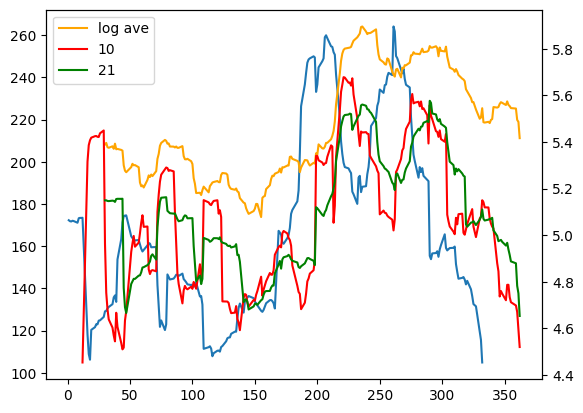

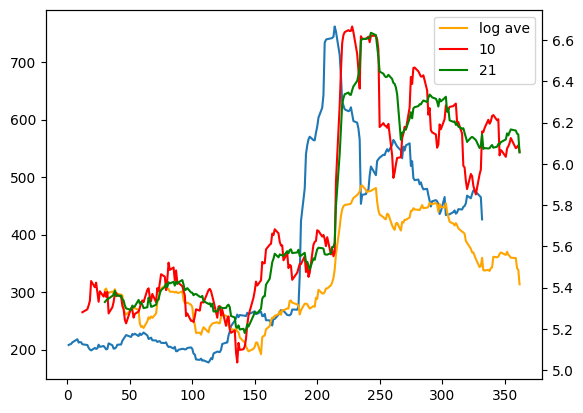

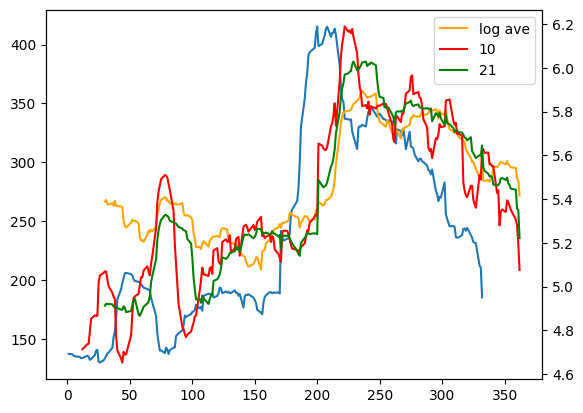

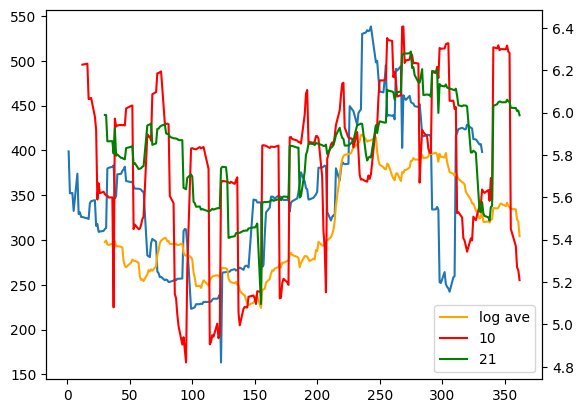

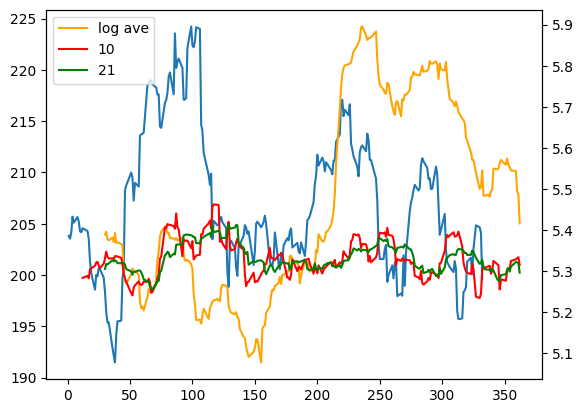

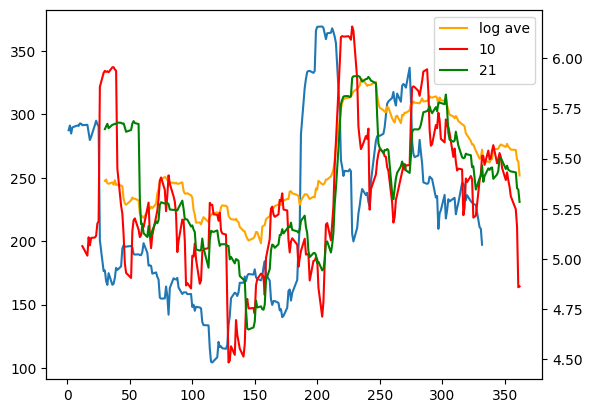

In [56]:
# for c in X.columns:
#     if c == "day":
#         continue
#     c1 = c.split("_")[0] + "_fwd"
#     print(f"=============={c}, {c1}===============")
#     plt.scatter(X[c], y[c1])
#     print(np.corrcoef(X[c], y[c1])[0, 1])
#     plt.show()

plot_log_sources = [
    f"{r}_avg{w}" for r in returns for w in [10, 21] if f"{r}_avg{w}" in X.columns
]
missing_plot_log_sources = [c for c in plot_log_sources if f"log_{c}" not in X.columns]
if missing_plot_log_sources:
    X = X.with_columns(
        [
            pl.when(pl.col(c) > 0)
            .then(pl.col(c).log())
            .otherwise(None)
            .alias(f"log_{c}")
            for c in missing_plot_log_sources
        ]
    )

vol_log_avg = sum([X[f"log_{r}_avg21"] / len(returns) for r in returns])
for r in returns:
    plt.plot(y["day"], y[f"{r}_fwd"])
    plt.twinx()
    plt.plot(X["day"], vol_log_avg, label="log ave", color="orange")
    # plt.plot(X["day"], X[f"log_{r}_avg5"], label="5", color="red")
    plt.plot(X["day"], X[f"log_{r}_avg10"], label="10", color="red")
    plt.plot(X["day"], X[f"log_{r}_avg21"], label="21", color="green")
    plt.legend()
    plt.show()

In [57]:
import itertools
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression


class PurgedWalkForwardCV:
    """Walk-forward CV for forward-looking targets.

    Train always precedes test; between them the last `purge` train rows are
    dropped --- their target window (horizon trading days) reaches into the
    test block, so keeping them would train the model on test-period outcomes.
    Because train is always before test there is no post-test embargo to do:
    purging the train tail removes the only leak path. Rows must be sorted by
    day, one consecutive trading day each.

    n_splits   : number of sequential test folds.
    purge      : rows dropped from the train tail; set to the target horizon.
    min_train  : rows before the first test fold.
    train_span : None -> expanding train window; int -> rolling window size.
    """

    def __init__(self, n_splits=5, purge=21, min_train=63, train_span=None):
        self.n_splits = n_splits
        self.purge = purge
        self.min_train = min_train
        self.train_span = train_span

    def split(self, X, y=None, groups=None):
        n = len(X)
        fold = (n - self.min_train) // self.n_splits
        if fold <= 0:
            raise ValueError("not enough rows for given n_splits / min_train")
        for k in range(self.n_splits):
            test_start = self.min_train + k * fold
            test_end = n if k == self.n_splits - 1 else test_start + fold
            train_end = test_start - self.purge
            if train_end <= 0:
                continue
            lo = 0 if self.train_span is None else max(0, train_end - self.train_span)
            yield np.arange(lo, train_end), np.arange(test_start, test_end)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


class PassthroughRegressor(BaseEstimator, RegressorMixin):
    """Dummy model: returns one feature column verbatim as the prediction.

    No fitting --- use it to score a precomputed forecast inside the same CV
    pipeline as the trainable models. To benchmark GARCH, call evaluate_model
    with features=["r{s}_garch_fwd"] and model=PassthroughRegressor().

    col : index of the feature column to pass through (0 = first feature).
    """

    def __init__(self, scale=1, col=0):
        self.col = col
        self.scale = scale

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.asarray(X)[:, self.col] * self.scale


# class LogLogLinearRegressor(BaseEstimator, RegressorMixin):
#     """Linear regression in log(feature) / log(target), predicted on original scale."""

#     def __init__(self, fit_intercept=True, eps=1e-12):
#         self.fit_intercept = fit_intercept
#         self.eps = eps

#     def _log_positive(self, values):
#         values = np.asarray(values, dtype=float)
#         return np.log(np.maximum(values, self.eps))

#     def fit(self, X, y):
#         self.model_ = LinearRegression(fit_intercept=self.fit_intercept)
#         self.model_.fit(self._log_positive(X), self._log_positive(y).ravel())
#         self.coef_ = self.model_.coef_
#         self.intercept_ = self.model_.intercept_
#         return self

#     def predict(self, X):
#         return np.exp(self.model_.predict(self._log_positive(X)))


# class ForwardStagewiseRegressor(BaseEstimator, RegressorMixin):
#     """Forward stagewise residual regression with fixed coefficients.

#     Features are normalized on each fit. At each step, regress the current
#     residual on every remaining normalized feature individually, select the
#     largest positive slope, fix that slope, and update the residual. Stop when
#     the best remaining slope is at or below min_coef.
#     """

#     def __init__(self, max_features=8, min_coef=0.0, feature_names=None):
#         self.max_features = max_features
#         self.min_coef = min_coef
#         self.feature_names = feature_names

#     def fit(self, X, y):
#         X = np.asarray(X, dtype=float)
#         y = np.asarray(y, dtype=float).ravel()
#         n_features = X.shape[1]
#         names = (
#             list(self.feature_names)
#             if self.feature_names is not None
#             else [f"x{i}" for i in range(n_features)]
#         )

#         self.mean_ = X.mean(axis=0)
#         self.scale_ = X.std(axis=0)
#         self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
#         Xn = (X - self.mean_) / self.scale_

#         selected = []
#         remaining = list(range(n_features))
#         intercept_norm = float(y.mean())
#         residual = y - intercept_norm
#         coef_norm = np.zeros(n_features)
#         self.selection_path_ = []
#         max_features = (
#             n_features
#             if self.max_features is None
#             else min(self.max_features, n_features)
#         )

#         for step in range(1, max_features + 1):
#             if not remaining:
#                 break

#             X_remaining = Xn[:, remaining]
#             denom = np.sum(X_remaining**2, axis=0)
#             slopes = np.full(len(remaining), -np.inf)
#             valid = denom > 0
#             slopes[valid] = (X_remaining[:, valid].T @ residual) / denom[valid]

#             best_pos = int(np.argmax(slopes))
#             best_slope = float(slopes[best_pos])
#             if best_slope <= self.min_coef:
#                 break

#             feature_idx = remaining.pop(best_pos)
#             selected.append(feature_idx)
#             coef_norm[feature_idx] = best_slope
#             residual = residual - best_slope * Xn[:, feature_idx]
#             self.selection_path_.append(
#                 {
#                     "step": step,
#                     "feature": names[feature_idx],
#                     "coef_norm": best_slope,
#                 }
#             )

#         coef = coef_norm / self.scale_
#         intercept = float(intercept_norm - np.dot(coef_norm, self.mean_ / self.scale_))

#         self.coef_ = coef
#         self.intercept_ = intercept
#         self.coef_norm_ = coef_norm
#         self.selected_idx_ = np.array(selected, dtype=int)
#         self.selected_feature_names_ = [names[i] for i in selected]
#         return self

#     def predict(self, X):
#         X = np.asarray(X, dtype=float)
#         return X @ self.coef_ + self.intercept_


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))


def qlike(y_true, y_pred, eps=1e-6):
    """QLIKE on variance forecasts; negative vol forecasts get near-zero variance."""
    true_vol = np.asarray(y_true, dtype=float)
    pred_vol = np.asarray(y_pred, dtype=float)
    true_var = np.maximum(true_vol, 0.0) ** 2 + eps
    pred_var = np.maximum(pred_vol, 0.0) ** 2 + eps
    ratio = true_var / pred_var
    return float(np.mean(ratio - np.log(ratio) - 1.0))


DEFAULT_LOSS_FNS = {"rmse": rmse, "mse": mse, "qlike": qlike}


def _normalize_loss_fns(loss_fns=None, scorer=None):
    if loss_fns is None:
        loss_fns = scorer if scorer is not None else DEFAULT_LOSS_FNS
    if isinstance(loss_fns, dict):
        return dict(loss_fns)
    if callable(loss_fns):
        name = getattr(loss_fns, "__name__", "loss")
        return {name: loss_fns}
    normalized = {}
    for i, fn in enumerate(loss_fns):
        base_name = getattr(fn, "__name__", f"loss_{i + 1}")
        name = base_name if base_name not in normalized else f"{base_name}_{i + 1}"
        normalized[name] = fn
    return normalized


def evaluate_model(
    X,
    y,
    model,
    features,
    target,
    param_grid=None,
    cv=None,
    horizon=21,
    day_col="day",
    loss_fns=None,
    primary_loss="rmse",
    scorer=None,
):
    """Purged walk-forward CV for one (features -> target) model.

    X, y    : day-keyed frames (make_features_targets output, + GARCH join);
              joined on `day_col`, sorted, null rows dropped.
    model   : an unfitted sklearn-style estimator (must be clone-able).
    features: feature column names in X the model is given.
    target  : target column name in y.
    param_grid : optional {param: [values]}; every combination is scored and
              the one with the lowest mean fold error wins.
    cv      : splitter; default PurgedWalkForwardCV(purge=horizon).
    loss_fns: dict/list/callable of (y_true, y_pred) -> loss; default
              {rmse, mse, qlike}. A single legacy `scorer` is still accepted.
    primary_loss : loss name used for model/parameter selection.

    Returns dict for the BEST param combo with:
      best_params, best_model (refit on all rows),
      <loss>_mean/std, train_<loss>_mean/std --- validation/training stats,
      cv_mean, train_cv_mean, fold_errors    --- aliases for primary_loss,
      r2, pred_mean, pred_std,               --- prediction stats (r2 = pooled OOF),
      train_r2, train_r2_std,                --- mean per-fold in-sample R^2,
      true_mean, true_std,                   --- target stats (pooled OOF),
      results (one row per param combo, sorted by error; also includes the
               per-combo r2 / pred / true stats).
    """
    loss_fns = _normalize_loss_fns(loss_fns, scorer=scorer)
    if primary_loss not in loss_fns:
        primary_loss = next(iter(loss_fns))
    primary_mean_col = f"{primary_loss}_mean"
    primary_std_col = f"{primary_loss}_std"
    cv = cv or PurgedWalkForwardCV(purge=horizon)
    d = (
        X.select([day_col, *features])
        .join(y.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    Xa, ya = d.select(features).to_numpy(), d.select(target).to_numpy().ravel()

    grid = param_grid or {}
    combos = [dict(zip(grid, v)) for v in itertools.product(*grid.values())]

    rows = []
    for params in combos:
        errs = {name: [] for name in loss_fns}
        train_errs = {name: [] for name in loss_fns}
        preds, trues = [], []
        train_r2_folds = []  # per-fold in-sample R^2
        for tr, te in cv.split(Xa):
            m = clone(model).set_params(**params)
            m.fit(Xa[tr], ya[tr])
            train_p = m.predict(Xa[tr])
            p = m.predict(Xa[te])
            for loss_name, loss_fn in loss_fns.items():
                train_errs[loss_name].append(loss_fn(ya[tr], train_p))
                errs[loss_name].append(loss_fn(ya[te], p))
            preds.append(p)
            trues.append(ya[te])
            ya_tr = ya[tr]
            ss_res_tr = float(np.sum((ya_tr - train_p) ** 2))
            ss_tot_tr = float(np.sum((ya_tr - ya_tr.mean()) ** 2))
            train_r2_folds.append(
                1.0 - ss_res_tr / ss_tot_tr if ss_tot_tr > 0 else float("nan")
            )
        errs = {name: np.asarray(values, dtype=float) for name, values in errs.items()}
        train_errs = {
            name: np.asarray(values, dtype=float) for name, values in train_errs.items()
        }
        preds = np.concatenate(preds)  # pooled out-of-fold predictions
        trues = np.concatenate(trues)
        ss_res = float(np.sum((trues - preds) ** 2))
        ss_tot = float(np.sum((trues - trues.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        train_r2_arr = np.asarray(train_r2_folds, dtype=float)
        train_r2 = (
            float(np.nanmean(train_r2_arr)) if train_r2_arr.size else float("nan")
        )
        train_r2_std = (
            float(np.nanstd(train_r2_arr)) if train_r2_arr.size else float("nan")
        )
        metric_stats = {}
        for loss_name in loss_fns:
            metric_stats[f"{loss_name}_mean"] = float(errs[loss_name].mean())
            metric_stats[f"{loss_name}_std"] = float(errs[loss_name].std())
            metric_stats[f"train_{loss_name}_mean"] = float(
                train_errs[loss_name].mean()
            )
            metric_stats[f"train_{loss_name}_std"] = float(train_errs[loss_name].std())
        rows.append(
            {
                **params,
                **metric_stats,
                "cv_mean": metric_stats[primary_mean_col],
                "cv_std": metric_stats[primary_std_col],
                "train_cv_mean": metric_stats[f"train_{primary_mean_col}"],
                "train_cv_std": metric_stats[f"train_{primary_std_col}"],
                "r2": r2,
                "train_r2": train_r2,
                "train_r2_std": train_r2_std,
                "pred_mean": float(preds.mean()),
                "pred_std": float(preds.std()),
                "true_mean": float(trues.mean()),
                "true_std": float(trues.std()),
                "_params": params,
                "_errs": errs,
                "_train_errs": train_errs,
            }
        )

    rows.sort(key=lambda r: r[primary_mean_col])
    best = rows[0]
    best_model = clone(model).set_params(**best["_params"]).fit(Xa, ya)
    results = pl.DataFrame(
        [{k: v for k, v in r.items() if not k.startswith("_")} for r in rows]
    )
    out = {
        "best_params": best["_params"],
        "best_model": best_model,
        "losses": list(loss_fns),
        "primary_loss": primary_loss,
        "cv_mean": best[primary_mean_col],
        "cv_std": best[primary_std_col],
        "train_cv_mean": best[f"train_{primary_mean_col}"],
        "train_cv_std": best[f"train_{primary_std_col}"],
        "r2": best["r2"],
        "train_r2": best["train_r2"],
        "train_r2_std": best["train_r2_std"],
        "pred_mean": best["pred_mean"],
        "pred_std": best["pred_std"],
        "true_mean": best["true_mean"],
        "true_std": best["true_std"],
        "fold_errors": best["_errs"][primary_loss],
        "train_fold_errors": best["_train_errs"][primary_loss],
        "results": results,
    }
    for loss_name in loss_fns:
        out[f"{loss_name}_mean"] = best[f"{loss_name}_mean"]
        out[f"{loss_name}_std"] = best[f"{loss_name}_std"]
        out[f"train_{loss_name}_mean"] = best[f"train_{loss_name}_mean"]
        out[f"train_{loss_name}_std"] = best[f"train_{loss_name}_std"]
        out[f"{loss_name}_fold_errors"] = best["_errs"][loss_name]
        out[f"train_{loss_name}_fold_errors"] = best["_train_errs"][loss_name]
    return out


def _r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")


def _fit_score_test_phase(
    joined,
    model,
    features,
    target,
    params,
    test_start_day,
    test_end_day=None,
    purge=21,
    train_span=None,
    day_col="day",
    loss_fns=None,
):
    loss_fns = _normalize_loss_fns(loss_fns)
    days = joined[day_col].to_numpy()
    test_mask = days >= test_start_day
    if test_end_day is not None:
        test_mask &= days <= test_end_day
    test_idx = np.flatnonzero(test_mask)
    if len(test_idx) == 0:
        raise ValueError("test phase has no rows after feature/target alignment")

    train_end = int(test_idx[0]) - int(purge)
    if train_end <= 0:
        raise ValueError("not enough purged pre-test rows to fit final model")
    train_start = 0 if train_span is None else max(0, train_end - int(train_span))
    train_idx = np.arange(train_start, train_end)
    if len(train_idx) == 0:
        raise ValueError("final train phase is empty")

    Xa = joined.select(features).to_numpy()
    ya = joined.select(target).to_numpy().ravel()
    final_model = clone(model).set_params(**(params or {}))
    final_model.fit(Xa[train_idx], ya[train_idx])
    train_pred = final_model.predict(Xa[train_idx])
    test_pred = final_model.predict(Xa[test_idx])

    test_metrics = {name: fn(ya[test_idx], test_pred) for name, fn in loss_fns.items()}
    final_train_metrics = {
        name: fn(ya[train_idx], train_pred) for name, fn in loss_fns.items()
    }
    return {
        "report_model": final_model,
        "test_days": days[test_idx],
        "test_true": ya[test_idx],
        "test_pred": test_pred,
        "final_train_days": days[train_idx],
        "final_train_true": ya[train_idx],
        "final_train_pred": train_pred,
        "test_metrics": test_metrics,
        "final_train_metrics": final_train_metrics,
        "test_r2": _r2_score(ya[test_idx], test_pred),
        "final_train_r2": _r2_score(ya[train_idx], train_pred),
        "test_pred_mean": float(np.mean(test_pred)),
        "test_pred_std": float(np.std(test_pred)),
        "test_true_mean": float(np.mean(ya[test_idx])),
        "test_true_std": float(np.std(ya[test_idx])),
        "test_period": f"{days[test_idx[0]]}-{days[test_idx[-1]]}",
        "final_train_period": f"{days[train_idx[0]]}-{days[train_idx[-1]]}",
    }


def evaluate_model_with_test(
    X,
    y,
    model,
    features,
    target,
    param_grid=None,
    cv=None,
    horizon=21,
    day_col="day",
    loss_fns=None,
    primary_loss="qlike",
    test_start_day=None,
    test_end_day=None,
    purge=21,
    train_span=None,
):
    if test_start_day is None:
        return evaluate_model(
            X,
            y,
            model,
            features,
            target,
            param_grid=param_grid,
            cv=cv,
            horizon=horizon,
            day_col=day_col,
            loss_fns=loss_fns,
            primary_loss=primary_loss,
        )

    joined = (
        X.select([day_col, *features])
        .join(y.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = joined[day_col].to_numpy()
    test_mask = days >= test_start_day
    if test_end_day is not None:
        test_mask &= days <= test_end_day
    test_idx = np.flatnonzero(test_mask)
    if len(test_idx) == 0:
        raise ValueError("test phase has no rows after feature/target alignment")
    # CV phase ends right at the test boundary: no purge needed between the
    # last CV val fold and the test phase. Within each fold the train tail is
    # already purged (PurgedWalkForwardCV) so train -> val cannot leak; and
    # the final training step in _fit_score_test_phase still purges its own
    # tail so train -> test cannot leak either.
    cv_end = int(test_idx[0])
    if cv_end <= 0:
        raise ValueError("not enough pre-test rows for CV")

    cv_frame = joined.head(cv_end)
    cv_result = evaluate_model(
        cv_frame.select([day_col, *features]),
        cv_frame.select([day_col, target]),
        model,
        features,
        target,
        param_grid=param_grid,
        cv=cv,
        horizon=horizon,
        day_col=day_col,
        loss_fns=loss_fns,
        primary_loss=primary_loss,
    )
    test_result = _fit_score_test_phase(
        joined,
        model,
        features,
        target,
        params=cv_result["best_params"],
        test_start_day=test_start_day,
        test_end_day=test_end_day,
        purge=purge,
        train_span=train_span,
        day_col=day_col,
        loss_fns=loss_fns,
    )
    cv_result.update(test_result)
    for loss_name, value in test_result["test_metrics"].items():
        cv_result[f"test_{loss_name}"] = value
    for loss_name, value in test_result["final_train_metrics"].items():
        cv_result[f"final_train_{loss_name}"] = value
    return cv_result

### single feature checking

In [58]:
# Market-level features: cross-stock arithmetic mean of log trailing RV features.
# mkt_logavg{w} = mean_x[log(avg RV_x over trailing w trading days)].
# w=1 collapses to log spot RV. These represent a "market" vol level and
# are added only to the single-feature correlation comparison below, not to
# the modelling specs in the next cell.
MKT_WINDOWS = [1, 5, 10, 21, 42, 63]
MKT_FEATURES = [f"mkt_logavg{w}" for w in MKT_WINDOWS]


def _build_market_log_avg_features(vols_frame, stock_cols, windows, day_col="day"):
    sorted_vols = vols_frame.sort(day_col)
    exprs = []
    for w in windows:
        per_stock = []
        for c in stock_cols:
            source_col = f"{c}_avg{w}" if w > 1 else c
            log_col = f"log_{source_col}"
            if log_col in sorted_vols.columns:
                per_stock.append(pl.col(log_col))
            else:
                per_stock.append(
                    pl.when(pl.col(source_col) > 0)
                    .then(pl.col(source_col).log())
                    .otherwise(None)
                )
        exprs.append(pl.mean_horizontal(per_stock).alias(f"mkt_logavg{w}"))
    return sorted_vols.select(day_col, *exprs)


_mkt_features_df = _build_market_log_avg_features(X, returns, MKT_WINDOWS)
# Idempotent: drop existing mkt columns from X before re-joining.
_existing_mkt = [c for c in MKT_FEATURES if c in X.columns]
if _existing_mkt:
    X = X.drop(_existing_mkt)
X = X.join(_mkt_features_df, on="day", how="left")


def market_level_candidates():
    return [(f"MKT log-avg{w}", f"mkt_logavg{w}") for w in MKT_WINDOWS]


def one_feature_candidates_for_stock(s, include_garch=True):
    candidates = [
        ("RV", s),
        ("avg5", f"{s}_avg5"),
        ("avg10", f"{s}_avg10"),
        ("avg21", f"{s}_avg21"),
        ("avg42", f"{s}_avg42"),
        ("avg63", f"{s}_avg63"),
        ("EWMA-1", f"{s}_ewma1"),
        ("EWMA-5", f"{s}_ewma5"),
        ("EWMA-10", f"{s}_ewma10"),
        # ("EWMA-11", f"{s}_ewma11"),
        # ("EWMA-15", f"{s}_ewma15"),
        ("EWMA-21", f"{s}_ewma21"),
        ("EWMA-42", f"{s}_ewma42"),
        ("EWMA-63", f"{s}_ewma63"),
    ]
    if include_garch:
        candidates.append(("GARCH fwd", f"{s}_garch_fwd"))
    return [(label, feat) for label, feat in candidates if feat in X.columns]


def cross_stock_one_feature_candidates(
    source_stocks=returns, include_garch=True, include_market=True
):
    candidates = []
    for source_stock in source_stocks:
        for feature_label, feature in one_feature_candidates_for_stock(
            source_stock, include_garch=include_garch
        ):
            candidates.append((source_stock, feature_label, feature))
    if include_market:
        for feature_label, feature in market_level_candidates():
            if feature in X.columns:
                candidates.append(("MKT", feature_label, feature))
    return candidates


def _filter_day_range(frame, start_day=None, end_day=None, day_col="day"):
    out = frame
    if start_day is not None:
        out = out.filter(pl.col(day_col) >= start_day)
    if end_day is not None:
        out = out.filter(pl.col(day_col) <= end_day)
    return out


FULL_CV = globals().get(
    "FULL_CV", {"n_splits": 1, "purge": 21, "min_train": 63, "train_span": None}
)
POST_SHIFT_START_DAY = globals().get("POST_SHIFT_START_DAY", 151)
POST_SHIFT_CV = globals().get(
    "POST_SHIFT_CV", {"n_splits": 1, "purge": 21, "min_train": 63, "train_span": None}
)


def _display_target_stock_tables(
    frame,
    stocks_to_eval=returns,
    stock_col="stock",
    table_label="Target stock",
    tbl_cols=32,
    tbl_rows=80,
):
    with pl.Config(tbl_cols=tbl_cols, tbl_rows=tbl_rows):
        for stock in stocks_to_eval:
            stock_frame = frame.filter(pl.col(stock_col) == stock)
            if stock_frame.height == 0:
                continue
            print(f"{table_label}: {stock}")
            display(stock_frame)


def compare_one_feature_models(
    label,
    X_frame,
    y_frame,
    stocks_to_eval=returns,
    source_stocks=returns,
    include_garch=True,
    start_day=None,
    end_day=None,
    day_col="day",
    display_rows=100,
    **_ignored,  # absorb legacy CV kwargs (n_splits, purge, min_train, ...)
):
    """Rank single features by Pearson r(feature_t, target_fwd) per target stock.

    Features are info<=t and target is the forward window t+1..t+21, so a
    positive r means the feature carries directional information for forecasting
    future realized vol.
    """
    X_eval = _filter_day_range(X_frame, start_day, end_day)
    candidate_features = [
        (source_stock, feature_label, feature)
        for source_stock, feature_label, feature in cross_stock_one_feature_candidates(
            source_stocks, include_garch=include_garch
        )
        if feature in X_eval.columns
    ]

    rows = []
    for s in stocks_to_eval:
        target = f"{s}_fwd"
        for source_stock, feature_label, feature in candidate_features:
            joined = (
                X_eval.select(day_col, feature)
                .join(y_frame.select(day_col, target), on=day_col)
                .drop_nulls()
                .drop_nans()
            )
            n = joined.height
            if n < 3:
                pearson = None
            else:
                arr_f = joined[feature].to_numpy()
                arr_t = joined[target].to_numpy()
                if np.std(arr_f) == 0 or np.std(arr_t) == 0:
                    pearson = None
                else:
                    pearson = float(np.corrcoef(arr_f, arr_t)[0, 1])
            rows.append(
                {
                    "stock": s,
                    "source_stock": source_stock,
                    "same_stock": source_stock == s,
                    "feature_label": feature_label,
                    "feature": feature,
                    "n": n,
                    "pearson": round(pearson, 4) if pearson is not None else None,
                    "abs_pearson": (
                        round(abs(pearson), 4) if pearson is not None else None
                    ),
                }
            )

    comp = (
        pl.DataFrame(rows)
        .sort(["stock", "pearson"], descending=[False, True], nulls_last=True)
        .with_columns(
            pl.col("pearson")
            .rank(method="ordinal", descending=True)
            .over("stock")
            .cast(pl.Int64)
            .alias("rank_corr")
        )
    )

    summary = (
        comp.group_by(["source_stock", "feature_label"], maintain_order=True)
        .agg(
            pl.col("rank_corr").mean().round(2).alias("mean_rank_corr"),
            pl.col("pearson").mean().round(3).alias("mean_pearson"),
            pl.col("abs_pearson").mean().round(3).alias("mean_abs_pearson"),
        )
        .sort("mean_pearson", descending=True, nulls_last=True)
    )

    print(label)
    print(
        f"Candidate features per target: {len(candidate_features)}; rows: {comp.height}"
    )
    print(
        "Pearson r(feature at t, target forward RV over t+1..t+21). Higher is better; r<=0 means no usable signal."
    )
    print("Rows are ranked within each target stock by Pearson r (descending).")
    _display_target_stock_tables(
        comp,
        stocks_to_eval=stocks_to_eval,
        tbl_cols=12,
        tbl_rows=display_rows,
    )
    print("Averaged over target stocks, ranked by mean Pearson r:")
    display(summary)
    return comp, summary


one_feature_full, one_feature_full_summary = compare_one_feature_models(
    "Full-year one-feature correlation",
    X,
    y,
    returns,
)

one_feature_post, one_feature_post_summary = compare_one_feature_models(
    f"Post-shift one-feature correlation, day >= {POST_SHIFT_START_DAY}",
    X,
    y,
    returns,
    start_day=POST_SHIFT_START_DAY,
)


# def compare_avg11_vs_ewma11_pass(comp, label):
#     own_stock = comp.filter(
#         pl.col("same_stock") & pl.col("feature_label").is_in(["avg11", "EWMA-11"])
#     )
#     wide = (
#         own_stock.select("stock", "feature_label", "pearson", "abs_pearson")
#         .pivot(values=["pearson", "abs_pearson"], index="stock", on="feature_label")
#         .with_columns(
#             (pl.col("pearson_EWMA-11") - pl.col("pearson_avg11"))
#             .round(4)
#             .alias("ewma11_minus_avg11_pearson"),
#             pl.when(pl.col("pearson_EWMA-11") >= pl.col("pearson_avg11"))
#             .then(pl.lit("EWMA-11"))
#             .otherwise(pl.lit("avg11"))
#             .alias("winner"),
#         )
#         .select(
#             "stock",
#             "pearson_avg11",
#             "pearson_EWMA-11",
#             "ewma11_minus_avg11_pearson",
#             "winner",
#         )
#     )
#     summary = own_stock.group_by("feature_label", maintain_order=True).agg(
#         pl.col("pearson").mean().round(4),
#         pl.col("abs_pearson").mean().round(4),
#     )
#     print(label)
#     display(wide)
#     print("Average same-stock Pearson:")
#     display(summary)
#     return wide, summary


# avg11_vs_ewma11_full, avg11_vs_ewma11_full_summary = compare_avg11_vs_ewma11_pass(
#     one_feature_full,
#     "Full-year same-stock Pearson: avg11 vs EWMA-11",
# )

# avg11_vs_ewma11_post, avg11_vs_ewma11_post_summary = compare_avg11_vs_ewma11_pass(
#     one_feature_post,
#     f"Post-shift same-stock Pearson: avg11 vs EWMA-11, day >= {POST_SHIFT_START_DAY}",
# )


def _feature_window_description(feature_label):
    if feature_label == "RV":
        return "daily RV at t"
    if feature_label.startswith("avg"):
        return f"trailing {feature_label[3:]} trading-day avg RV through t"
    if feature_label.startswith("EWMA-"):
        return f"EWMA half-life {feature_label.split('-')[-1]} trading days through t"
    if feature_label == "GARCH fwd":
        return "GARCH forward vol forecast from info through t"
    return feature_label


def identify_lead_lag_from_top_features(
    comp,
    label,
    top_n=5,
    stocks_to_eval=returns,
    cross_stock_only=True,
):
    frame = (
        comp.filter((~pl.col("same_stock")) & (pl.col("source_stock") != "MKT"))
        if cross_stock_only
        else comp
    )
    top = (
        frame.sort(["stock", "rank_corr"])
        .group_by("stock", maintain_order=True)
        .head(top_n)
        .with_columns(
            pl.format("{} -> {}", pl.col("source_stock"), pl.col("stock")).alias(
                "lead_lag_edge"
            ),
            pl.col("feature_label")
            .map_elements(_feature_window_description, return_dtype=pl.String)
            .alias("source_window"),
            pl.when(pl.col("pearson") > 0)
            .then(pl.lit("positive"))
            .when(pl.col("pearson") < 0)
            .then(pl.lit("negative"))
            .otherwise(pl.lit("zero"))
            .alias("relation_sign"),
        )
        .select(
            "stock",
            "rank_corr",
            "lead_lag_edge",
            "source_stock",
            "feature_label",
            "feature",
            "source_window",
            "pearson",
            "abs_pearson",
            "relation_sign",
        )
    )
    edges = (
        top.group_by(["source_stock", "stock", "lead_lag_edge"], maintain_order=True)
        .agg(
            pl.len().alias("top5_feature_count"),
            pl.col("rank_corr").mean().round(2).alias("mean_rank"),
            pl.col("pearson").mean().round(3).alias("mean_pearson"),
            pl.col("feature_label").str.join(", ").alias("top_features"),
            pl.col("relation_sign").str.join(", ").alias("signs"),
        )
        .sort(
            ["top5_feature_count", "mean_rank", "mean_pearson"],
            descending=[True, False, True],
        )
    )
    source_summary = (
        top.group_by("source_stock", maintain_order=True)
        .agg(
            pl.len().alias("top5_appearances"),
            pl.n_unique("stock").alias("n_targets_led"),
            pl.col("pearson").mean().round(3).alias("mean_pearson"),
            pl.col("stock").unique().str.join(", ").alias("targets_led"),
        )
        .sort(
            ["top5_appearances", "n_targets_led", "mean_pearson"],
            descending=[True, True, True],
        )
    )
    print(label)
    print(
        f"Top {top_n} cross-stock non-market features per target, ranked by Pearson r(feature_t, target_fwd). Edge means source feature at t correlates with target fwd RV over t+1..t+21."
    )
    _display_target_stock_tables(
        top, stocks_to_eval=stocks_to_eval, tbl_cols=14, tbl_rows=top_n
    )
    print("Repeated directed lead-lag edges among those top features:")
    display(edges)
    print("Leading source stocks among top features:")
    display(source_summary)
    return top, edges, source_summary


lead_lag_full, lead_lag_full_edges, lead_lag_full_sources = (
    identify_lead_lag_from_top_features(
        one_feature_full,
        "Full-year lead-lag from top one-feature correlations",
    )
)

lead_lag_post, lead_lag_post_edges, lead_lag_post_sources = (
    identify_lead_lag_from_top_features(
        one_feature_post,
        f"Post-shift lead-lag from top one-feature correlations, day >= {POST_SHIFT_START_DAY}",
    )
)

Full-year one-feature correlation
Candidate features per target: 84; rows: 504
Pearson r(feature at t, target forward RV over t+1..t+21). Higher is better; r<=0 means no usable signal.
Rows are ranked within each target stock by Pearson r (descending).
Target stock: ra


stock,source_stock,same_stock,feature_label,feature,n,pearson,abs_pearson,rank_corr
str,str,bool,str,str,i64,f64,f64,i64
"""ra""","""rc""",false,"""avg10""","""rc_avg10""",222,0.5535,0.5535,1
"""ra""","""rc""",false,"""avg5""","""rc_avg5""",227,0.5392,0.5392,2
"""ra""","""rd""",false,"""EWMA-5""","""rd_ewma5""",231,0.5385,0.5385,3
"""ra""","""rc""",false,"""EWMA-5""","""rc_ewma5""",231,0.5199,0.5199,4
"""ra""","""rc""",false,"""EWMA-1""","""rc_ewma1""",231,0.5083,0.5083,5
"""ra""","""rc""",false,"""avg21""","""rc_avg21""",211,0.4997,0.4997,6
"""ra""","""rc""",false,"""EWMA-10""","""rc_ewma10""",231,0.4988,0.4988,7
"""ra""","""MKT""",false,"""MKT log-avg5""","""mkt_logavg5""",227,0.4982,0.4982,8
"""ra""","""MKT""",false,"""MKT log-avg10""","""mkt_logavg10""",222,0.4982,0.4982,9


Target stock: rb


stock,source_stock,same_stock,feature_label,feature,n,pearson,abs_pearson,rank_corr
str,str,bool,str,str,i64,f64,f64,i64
"""rb""","""rc""",false,"""avg10""","""rc_avg10""",222,0.813,0.813,1
"""rb""","""rc""",false,"""EWMA-5""","""rc_ewma5""",231,0.8027,0.8027,2
"""rb""","""rc""",false,"""avg5""","""rc_avg5""",227,0.7955,0.7955,3
"""rb""","""rc""",false,"""EWMA-10""","""rc_ewma10""",231,0.7814,0.7814,4
"""rb""","""rc""",false,"""avg21""","""rc_avg21""",211,0.7679,0.7679,5
"""rb""","""rc""",false,"""EWMA-1""","""rc_ewma1""",231,0.7645,0.7645,6
"""rb""","""rc""",false,"""EWMA-21""","""rc_ewma21""",231,0.7511,0.7511,7
"""rb""","""rc""",false,"""EWMA-42""","""rc_ewma42""",231,0.7323,0.7323,8
"""rb""","""rc""",false,"""EWMA-63""","""rc_ewma63""",231,0.7248,0.7248,9


Target stock: rc


...

stock,rank_corr,lead_lag_edge,source_stock,feature_label,feature,source_window,pearson,abs_pearson,relation_sign
str,i64,str,str,str,str,str,f64,f64,str
"""rf""",1,"""rd -> rf""","""rd""","""avg21""","""rd_avg21""","""trailing 21 trading-day avg RV…",0.4117,0.4117,"""positive"""
"""rf""",2,"""rd -> rf""","""rd""","""EWMA-5""","""rd_ewma5""","""EWMA half-life 5 trading days …",0.4079,0.4079,"""positive"""
"""rf""",3,"""rd -> rf""","""rd""","""EWMA-10""","""rd_ewma10""","""EWMA half-life 10 trading days…",0.3629,0.3629,"""positive"""
"""rf""",4,"""rc -> rf""","""rc""","""avg5""","""rc_avg5""","""trailing 5 trading-day avg RV …",0.3603,0.3603,"""positive"""
"""rf""",5,"""rd -> rf""","""rd""","""avg10""","""rd_avg10""","""trailing 10 trading-day avg RV…",0.3443,0.3443,"""positive"""


Repeated directed lead-lag edges among those top features:


source_stock,stock,lead_lag_edge,top5_feature_count,mean_rank,mean_pearson,top_features,signs
str,str,str,u32,f64,f64,str,str
"""ra""","""rc""","""ra -> rc""",5,6.0,0.371,"""avg10, avg5, EWMA-5, avg21, EW…","""positive, positive, positive, …"
"""rc""","""rb""","""rc -> rb""",4,2.5,0.598,"""avg5, avg10, EWMA-1, EWMA-5""","""positive, positive, positive, …"
"""ra""","""re""","""ra -> re""",4,2.5,0.562,"""avg10, EWMA-5, avg5, avg21""","""positive, positive, positive, …"
"""rd""","""rf""","""rd -> rf""",4,2.75,0.382,"""avg21, EWMA-5, EWMA-10, avg10""","""positive, positive, positive, …"
"""rd""","""ra""","""rd -> ra""",3,2.33,0.347,"""avg10, EWMA-5, avg5""","""positive, positive, positive"""
…,…,…,…,…,…,…,…
"""rc""","""ra""","""rc -> ra""",2,4.0,0.314,"""avg5, EWMA-1""","""positive, positive"""
"""re""","""rd""","""re -> rd""",1,2.0,0.61,"""avg21""","""positive"""
"""rc""","""rf""","""rc -> rf""",1,4.0,0.36,"""avg5""","""positive"""


Leading source stocks among top features:


source_stock,top5_appearances,n_targets_led,mean_pearson,targets_led
str,u32,u32,f64,str
"""rc""",10,5,0.506,"""ra, rb, rd, re, rf"""
"""ra""",10,3,0.465,"""rb, rc, re"""
"""rd""",7,2,0.367,"""ra, rf"""
"""rb""",2,1,0.601,"""rd"""
"""re""",1,1,0.61,"""rd"""


### modeling

In [97]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def get_har_feats(s, windows: list[int]):
    return [f"{s}_avg{i}" if i > 1 else s for i in windows]
def ewmaify(feats):
    return [c.replace("avg", "ewma") for c in feats]
har_base_cols = sorted(
    {
        c
        for s in returns
        for c in get_har_feats(s, windows) + ewmaify(get_har_feats(s, windows))
    }
)
X = X.with_columns(
    [
        pl.when(pl.col(c) > 0).then(pl.col(c).log()).otherwise(None).alias(f"log_{c}")
        for c in har_base_cols
    ]
)

# Common rows so every model in a date range is scored on the same purged CV windows.
Xc = X.drop_nulls().drop_nans()
ALL_STOCK_AVG_EWMA_FEATURES = [c for c in har_base_cols if c in X.columns]
ALL_STOCK_LOG_AVG_EWMA_FEATURES = [
    f"log_{c}" for c in ALL_STOCK_AVG_EWMA_FEATURES if f"log_{c}" in X.columns
]

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0]
L1_RATIO_GRID = [0.1, 0.5, 0.9]
STAGEWISE_MAX_FEATURES = 8
STAGEWISE_MIN_COEF = 0.0
FULL_CV = {
    "n_splits": 1,
    "purge": 21,
    "min_train": 63,
    "train_span": None,
}
POST_SHIFT_START_DAY = 151
POST_SHIFT_CV = {
    "n_splits": 1,
    "purge": 21,
    "min_train": 63,
    "train_span": None,
}
REPORT_RANK_METRIC = "qlike"
TEST_START_DAY = 300
FULL_TEST_START_DAY = TEST_START_DAY
POST_SHIFT_TEST_START_DAY = TEST_START_DAY


def stagewise_features_for_stock(s):
    return ALL_STOCK_AVG_EWMA_FEATURES

def get_scale(feature: str) -> int:
    import re   
    m = re.search(r"_(?:avg|ewma)(\d+)", feature)
    hdays = int(m.group(1)) if m else 1
    return np.sqrt(21 / hdays)
    
def model_specs_for_stock(s):
    # har_feats = [s, f"{s}_avg5", f"{s}_avg21"] # standard HAR
    # har_ewma11_feats = [*har_feats, f"{s}_ewma11"] # ewma HAR
    # ewma_har_feats = [f"{s}_ewma5", f"{s}_ewma11", f"{s}_ewma21"] # ewma HAR
    # long_har_feats = []
    # log_har_feats = [f"log_{c}" for c in har_feats] # log HAR
    # log_ewma_har_feats = [f"log_{c}" for c in ewma_har_feats] # log ewma HAR
    # all_stock_log_avg_ewma_feats = ALL_STOCK_LOG_AVG_EWMA_FEATURES
    # stagewise_feats = stagewise_features_for_stock(s)
    def logify(feats):
        return [f"log_{c}" for c in feats]
    har_windows = [1, 5, 21] # day, week, month
    week_windows = [5, 10, 21, 42, 63]
    baseline_windows = [1, 5, 10, 21, 42, 63]
    har_feats = get_har_feats(s, har_windows)
    whar_feats = get_har_feats(s, week_windows)
    baseline_feats = get_har_feats(s, baseline_windows)
    def get_log_transformed_target_regressor(regressor):
        return TransformedTargetRegressor(
                    regressor=regressor,
                    func=np.log,
                    inverse_func=np.exp,
                    check_inverse=False,
                )
        
    def get_specs(feats, prefix=""):
        return  [
            (
                prefix + "HAR (LinReg)", 
                 make_pipeline(StandardScaler(), LinearRegression()),
                 feats, None
            ),
            (
                prefix + "HAR (Ridge scaled)",
                make_pipeline(StandardScaler(), Ridge()),
                feats,
                {"ridge__alpha": ALPHA_GRID},
            ),
            (
                prefix + "log HAR (LinReg)", 
                get_log_transformed_target_regressor(
                    make_pipeline(StandardScaler(), LinearRegression()),
                ), 
                logify(feats), 
                None
            ),
            (
                prefix + "log HAR (Ridge scaled)",
                get_log_transformed_target_regressor(
                    make_pipeline(StandardScaler(), Ridge()),
                ), 
                logify(feats),
                {"regressor__ridge__alpha": ALPHA_GRID},
            ),
        ]
    return (
        get_specs(har_feats)
        + get_specs(whar_feats)
        + get_specs(ewmaify(har_feats), "ewma ")
        + get_specs(ewmaify(whar_feats), "ewma ")
        + [(b, PassthroughRegressor(scale=get_scale(b)), [b], None) for b in baseline_feats]
        + [(b, PassthroughRegressor(scale=get_scale(b)), [b], None) for b in ewmaify(baseline_feats)]
        + [("GARCH (pass)", PassthroughRegressor(), [f"{s}_garch_fwd"], None)]
    )


def _best_str(p):
    if not p:
        return "-"
    # strip sklearn pipeline prefix (e.g. "ridge__alpha" -> "alpha")
    return ", ".join(f"{k.split('__')[-1]}={v:g}" for k, v in p.items())


def _fold_str(errors):
    return "[" + ", ".join(f"{e:.2f}" for e in errors) + "]"


# def _selected_features_str(model):
#     features = getattr(model, "selected_feature_names_", None)
#     return ", ".join(features) if features else "-"


# def _first_selected_feature(model):
#     features = getattr(model, "selected_feature_names_", None)
#     return features[0] if features else "-"


# def _stagewise_coef_str(model):
#     selected = getattr(model, "selected_idx_", None)
#     coef = getattr(model, "coef_", None)
#     names = getattr(model, "feature_names", None)
#     if selected is None or coef is None or names is None or len(selected) == 0:
#         return "-"
#     return ", ".join(f"{names[i]}={coef[i]:.3g}" for i in selected)


# def _stagewise_intercept_str(model):
#     if not hasattr(model, "selected_idx_"):
#         return "-"
#     intercept = getattr(model, "intercept_", None)
#     return "-" if intercept is None else f"{intercept:.3g}"


def _fold_table(X_eval, y_frame, cv, day_col="day"):
    eval_frame = (
        X_eval.select(day_col)
        .join(y_frame, on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = eval_frame[day_col].to_numpy()
    rows = []
    for i, (tr, te) in enumerate(cv.split(eval_frame), start=1):
        rows.append(
            {
                "fold": i,
                "train_days": f"{days[tr[0]]}-{days[tr[-1]]}",
                "test_days": f"{days[te[0]]}-{days[te[-1]]}",
                "n_train": len(tr),
                "n_test": len(te),
            }
        )
    return pl.DataFrame(rows), eval_frame


def _report_row(stock, name, feats, r):
    has_test = "test_metrics" in r
    report_model = r.get("report_model", r["best_model"])
    row = {
        "stock": stock,
        "model": name,
        "features": ", ".join(feats),
        "primary_loss": r.get("primary_loss", "qlike"),
    }
    for loss_name in r.get("losses", ["rmse"]):
        row[f"cv_{loss_name}"] = round(r[f"{loss_name}_mean"], 3)
        row[f"cv_train_{loss_name}"] = round(r[f"train_{loss_name}_mean"], 3)
        row[f"cv_{loss_name}_std"] = round(r[f"{loss_name}_std"], 3)
        row[f"cv_train_{loss_name}_std"] = round(r[f"train_{loss_name}_std"], 3)
        if has_test:
            row[f"test_{loss_name}"] = round(r["test_metrics"][loss_name], 3)
            row[f"final_train_{loss_name}"] = round(
                r["final_train_metrics"][loss_name], 3
            )
        # val_* / train_* are the selection metric: always the CV-phase score.
        # test_* is kept as a separate column for honest held-out evaluation.
        row[f"val_{loss_name}"] = row[f"cv_{loss_name}"]
        row[f"train_{loss_name}"] = row[f"cv_train_{loss_name}"]
        row[f"val_{loss_name}_std"] = row[f"cv_{loss_name}_std"]
        row[f"train_{loss_name}_std"] = row[f"cv_train_{loss_name}_std"]
    row.update(
        {
            "cv_train_folds": _fold_str(r["train_fold_errors"]),
            "cv_val_folds": _fold_str(r["fold_errors"]),
            "train_folds": _fold_str(r["train_fold_errors"]),
            "val_folds": _fold_str(r["fold_errors"]),
            "cv_r2": round(r["r2"], 3),
            "cv_train_r2": round(r["train_r2"], 3),
            # Selection-aligned display: r2 / pred_* / true_* now reflect the
            # CV-phase prediction stats. Held-out test versions remain in the
            # test_r2 / test_pred_mean / test_true_mean / etc. columns.
            "r2": round(r["r2"], 3),
            "train_r2": round(r["train_r2"], 3),
            "train_r2_std": round(r["train_r2_std"], 3),
            "pred_mean": round(r["pred_mean"], 3),
            "pred_std": round(r["pred_std"], 3),
            "true_mean": round(r["true_mean"], 3),
            "true_std": round(r["true_std"], 3),
            "test_r2": round(r["test_r2"], 3) if has_test else None,
            "test_pred_mean": (round(r["test_pred_mean"], 3) if has_test else None),
            "test_pred_std": (round(r["test_pred_std"], 3) if has_test else None),
            "test_true_mean": (round(r["test_true_mean"], 3) if has_test else None),
            "test_true_std": (round(r["test_true_std"], 3) if has_test else None),
            "test_days": r.get("test_period", "-"),
            "final_train_days": r.get("final_train_period", "-"),
            "best": _best_str(r["best_params"]),
            # "first_feature": _first_selected_feature(report_model),
            # "selected_features": _selected_features_str(report_model),
            # "stagewise_intercept": _stagewise_intercept_str(report_model),
            # "stagewise_coefs": _stagewise_coef_str(report_model),
        }
    )
    return row


def summarize_report(report, prefix=None):
    metric_cols = [
        c
        for c in report.columns
        if c.startswith(("test_", "final_train_", "cv_", "cv_train_", "val_", "train_"))
        and not c.endswith(("folds", "days"))
        and hasattr(report.schema[c], "is_numeric")
        and report.schema[c].is_numeric()
    ]
    exprs = [pl.col(c).mean().round(3).alias(c) for c in metric_cols]
    exprs.append(pl.col("r2").mean().round(3).alias("r2"))
    summary = report.group_by("model", maintain_order=True).agg(exprs)
    if prefix is not None:
        summary = summary.rename(
            {c: f"{prefix}_{c}" for c in summary.columns if c != "model"}
        )
    return summary


def _display_target_stock_tables(
    frame,
    stocks_to_eval=returns,
    stock_col="stock",
    table_label="Target stock",
    tbl_cols=32,
    tbl_rows=80,
):
    with pl.Config(tbl_cols=tbl_cols, tbl_rows=tbl_rows):
        for stock in stocks_to_eval:
            stock_frame = frame.filter(pl.col(stock_col) == stock)
            if stock_frame.height == 0:
                continue
            print(f"{table_label}: {stock}")
            display(stock_frame)


def run_model_report(
    label,
    X_frame,
    y_frame,
    stocks_to_eval=returns,
    start_day=None,
    end_day=None,
    n_splits=5,
    purge=21,
    min_train=63,
    train_span=None,
    test_start_day=None,
    test_end_day=None,
    horizon=21,
    loss_fns=None,
    primary_loss=REPORT_RANK_METRIC,
    rank_metric=REPORT_RANK_METRIC,
    display_rows=80,
):
    cv = PurgedWalkForwardCV(
        n_splits=n_splits,
        purge=purge,
        min_train=min_train,
        train_span=train_span,
    )
    X_eval = _filter_day_range(X_frame, start_day, end_day).drop_nulls().drop_nans()
    X_sorted = X_eval.sort("day")
    X_cv_display = X_sorted
    if test_start_day is not None:
        days = X_sorted["day"].to_numpy()
        test_mask = days >= test_start_day
        if test_end_day is not None:
            test_mask &= days <= test_end_day
        test_pos = np.flatnonzero(test_mask)
        if len(test_pos) == 0:
            raise ValueError("test phase has no rows in X_eval")
        X_cv_display = X_sorted.head(max(0, int(test_pos[0]) - int(purge)))
    folds, eval_frame = _fold_table(X_cv_display, y_frame, cv)

    rows = []
    model_results = {}
    for s in stocks_to_eval:
        for name, model, feats, grid in model_specs_for_stock(s):
            r = evaluate_model_with_test(
                X_eval,
                y_frame,
                model,
                feats,
                f"{s}_fwd",
                param_grid=grid,
                cv=cv,
                horizon=horizon,
                loss_fns=loss_fns,
                primary_loss=primary_loss,
                test_start_day=test_start_day,
                test_end_day=test_end_day,
                purge=purge,
                train_span=train_span,
            )
            model_results[(s, name)] = r
            rows.append(_report_row(s, name, feats, r))

    report = pl.DataFrame(rows)
    # Model selection: always sort by val_<rank_metric> (= cv_<rank_metric>).
    # test_<rank_metric> stays in the columns for inspection but is never the
    # ranking target.
    sort_loss_col = f"val_{rank_metric}"
    if sort_loss_col not in report.columns:
        sort_loss_col = (
            f"val_{primary_loss}"
            if f"val_{primary_loss}" in report.columns
            else "val_rmse"
        )
    sort_std_col = f"{sort_loss_col}_std"
    sort_cols = ["stock", sort_loss_col]
    if sort_std_col in report.columns:
        sort_cols.append(sort_std_col)
    first_cols = ["model", "features", "primary_loss", *sort_cols]
    report = report.sort(sort_cols).select(
        first_cols + [c for c in report.columns if c not in first_cols]
    )
    
    summary = summarize_report(report)
    if sort_loss_col in summary.columns:
        summary = summary.sort(sort_loss_col)
    print(label)
    print(f"Rows: X={X_eval.shape}, CV eval={eval_frame.shape}")
    if test_start_day is not None:
        end_txt = "end" if test_end_day is None else test_end_day
        print(
            f"Test phase: day >= {test_start_day} and <= {end_txt}; CV and final train purge {purge} rows before test."
        )
    display(folds)
    print(
        "CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present."
    )
    rank_text = sort_loss_col
    if sort_std_col in report.columns:
        rank_text = f"{rank_text} and then {sort_std_col}"
    print(f"Rows are ranked within stock by {rank_text}.")
    _display_target_stock_tables(
        report,
        stocks_to_eval=stocks_to_eval,
        tbl_cols=32,
        tbl_rows=display_rows,
    )
    print(f"Averaged over the {len(stocks_to_eval)} stocks:")
    with pl.Config(tbl_cols=32):
        display(summary)
    return {
        "label": label,
        "X": X_eval,
        "cv": cv,
        "folds": folds,
        "report": report,
        "summary": summary,
        "model_results": model_results,
        "test_start_day": test_start_day,
        "test_end_day": test_end_day,
        "purge": purge,
        "train_span": train_span,
    }

In [98]:
full_eval = run_model_report(
    "Full-year CV + held-out test",
    X,
    y,
    returns,
    test_start_day=FULL_TEST_START_DAY,
    **FULL_CV,
)
report = full_eval["report"]
full_summary = summarize_report(report, prefix="full")

Full-year CV + held-out test
Rows: X=(185, 157), CV eval=(122, 7)
Test phase: day >= 300 and <= end; CV and final train purge 21 rows before test.


fold,train_days,test_days,n_train,n_test
i64,str,str,i64,i64
1,"""92-155""","""186-270""",42,59


CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present.
Rows are ranked within stock by val_qlike and then val_qlike_std.
Target stock: ra


model,features,primary_loss,stock,val_qlike,val_qlike_std,cv_rmse,cv_train_rmse,cv_rmse_std,cv_train_rmse_std,test_rmse,final_train_rmse,val_rmse,train_rmse,val_rmse_std,train_rmse_std,…,cv_train_r2,r2,train_r2,train_r2_std,pred_mean,pred_std,true_mean,true_std,test_r2,test_pred_mean,test_pred_std,test_true_mean,test_true_std,test_days,final_train_days,best
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""ra_ewma10""","""ra_ewma10""","""qlike""","""ra""",0.221,0.0,90.199,58.088,0.0,0.0,111.17,61.264,90.199,58.088,0.0,0.0,…,-21.639,-7.447,-21.639,0.0,270.635,46.987,216.749,31.035,-51.203,254.265,15.245,143.801,15.386,"""302-332""","""92-270""","""-"""
"""ra_avg21""","""ra_avg21""","""qlike""","""ra""",0.277,0.0,67.915,23.945,0.0,0.0,45.513,51.668,67.915,23.945,0.0,0.0,…,-2.847,-3.789,-2.847,0.0,208.793,40.203,216.749,31.035,-7.75,185.774,26.271,143.801,15.386,"""302-332""","""92-270""","""-"""
"""ra_avg10""","""ra_avg10""","""qlike""","""ra""",0.342,0.0,130.659,69.581,0.0,0.0,97.667,89.326,130.659,69.581,0.0,0.0,…,-31.485,-16.725,-31.485,0.0,309.373,70.247,216.749,31.035,-39.292,236.696,29.834,143.801,15.386,"""302-332""","""92-270""","""-"""
"""ra_ewma21""","""ra_ewma21""","""qlike""","""ra""",0.411,0.0,69.314,15.268,0.0,0.0,41.55,57.082,69.314,15.268,0.0,0.0,…,-0.564,-3.988,-0.564,0.0,172.186,26.978,216.749,31.035,-6.292,183.874,6.745,143.801,15.386,"""302-332""","""92-270""","""-"""
"""GARCH (pass)""","""ra_garch_fwd""","""qlike""","""ra""",0.418,0.0,74.064,18.145,0.0,0.0,39.378,58.0,74.064,18.145,0.0,0.0,…,-1.209,-4.695,-1.209,0.0,172.213,32.719,216.749,31.035,-5.55,175.283,9.603,143.801,15.386,"""302-332""","""92-270""","""-"""
"""ra_ewma5""","""ra_ewma5""","""qlike""","""ra""",0.574,0.0,209.093,126.228,0.0,0.0,190.225,152.427,209.093,126.228,0.0,0.0,…,-105.906,-44.393,-105.906,0.0,399.4,79.078,216.749,31.035,-151.847,332.531,22.139,143.801,15.386,"""302-332""","""92-270""","""-"""
"""ra_avg5""","""ra_avg5""","""qlike""","""ra""",0.683,0.0,260.552,147.17,0.0,0.0,186.496,192.801,260.552,147.17,0.0,0.0,…,-144.323,-69.485,-144.323,0.0,435.91,126.723,216.749,31.035,-145.913,324.513,37.063,143.801,15.386,"""302-332""","""92-270""","""-"""
"""log HAR (Ridge scaled)""","""log_ra_avg5, log_ra_avg10, log…","""qlike""","""ra""",1.065,0.0,90.658,7.437,0.0,0.0,37.63,43.695,90.658,7.437,0.0,0.0,…,0.629,-7.533,0.629,0.0,145.394,35.389,216.749,31.035,-4.981,179.036,11.453,143.801,15.386,"""302-332""","""92-270""","""alpha=1"""
"""ewma log HAR (LinReg)""","""log_ra_ewma5, log_ra_ewma10, l…","""qlike""","""ra""",1.071,0.0,456.896,2.22,0.0,0.0,251.526,8.684,456.896,2.22,0.0,0.0,…,0.967,-215.743,0.967,0.0,577.065,266.553,216.749,31.035,-266.233,379.37,73.753,143.801,15.386,"""302-332""","""92-270""","""-"""


Target stock: rb


...

model,features,primary_loss,stock,val_qlike,val_qlike_std,cv_rmse,cv_train_rmse,cv_rmse_std,cv_train_rmse_std,test_rmse,final_train_rmse,val_rmse,train_rmse,val_rmse_std,train_rmse_std,…,cv_train_r2,r2,train_r2,train_r2_std,pred_mean,pred_std,true_mean,true_std,test_r2,test_pred_mean,test_pred_std,test_true_mean,test_true_std,test_days,final_train_days,best
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""ewma log HAR (Ridge scaled)""","""log_re, log_re_ewma5, log_re_e…","""qlike""","""re""",0.001,0.0,4.904,3.437,0.0,0.0,7.376,3.974,4.904,3.437,0.0,0.0,…,0.798,0.0,0.798,0.0,211.255,3.62,208.104,4.905,-6.311,207.767,1.005,200.735,2.728,"""302-332""","""92-270""","""alpha=10"""
"""log HAR (LinReg)""","""log_re, log_re_avg5, log_re_av…","""qlike""","""re""",0.001,0.0,5.097,7.636,0.0,0.0,7.099,6.29,5.097,7.636,0.0,0.0,…,0.004,-0.08,0.004,0.0,207.891,0.43,208.104,4.905,-5.773,207.255,0.179,200.735,2.728,"""302-332""","""92-270""","""-"""
"""log HAR (Ridge scaled)""","""log_re, log_re_avg5, log_re_av…","""qlike""","""re""",0.001,0.0,5.056,7.636,0.0,0.0,7.101,6.29,5.056,7.636,0.0,0.0,…,0.004,-0.062,0.004,0.0,208.026,0.354,208.104,4.905,-5.776,207.258,0.17,200.735,2.728,"""302-332""","""92-270""","""alpha=10"""
"""HAR (Ridge scaled)""","""re, re_avg5, re_avg21""","""qlike""","""re""",0.001,0.0,5.041,7.638,0.0,0.0,7.185,6.289,5.041,7.638,0.0,0.0,…,0.003,-0.056,0.003,0.0,208.208,0.314,208.104,4.905,-5.937,207.349,0.147,200.735,2.728,"""302-332""","""92-270""","""alpha=10"""
"""ewma HAR (LinReg)""","""re, re_ewma5, re_ewma21""","""qlike""","""re""",0.001,0.0,5.353,2.555,0.0,0.0,7.522,3.791,5.353,2.555,0.0,0.0,…,0.889,-0.191,0.889,0.0,211.736,4.762,208.104,4.905,-6.603,207.841,1.459,200.735,2.728,"""302-332""","""92-270""","""-"""
"""ewma HAR (Ridge scaled)""","""re, re_ewma5, re_ewma21""","""qlike""","""re""",0.001,0.0,4.993,3.465,0.0,0.0,7.466,3.991,4.993,3.465,0.0,0.0,…,0.795,-0.036,0.795,0.0,211.402,3.639,208.104,4.905,-6.492,207.876,1.019,200.735,2.728,"""302-332""","""92-270""","""alpha=10"""
"""ewma log HAR (LinReg)""","""log_re, log_re_ewma5, log_re_e…","""qlike""","""re""",0.001,0.0,5.263,2.512,0.0,0.0,7.453,3.753,5.263,2.512,0.0,0.0,…,0.892,-0.151,0.892,0.0,211.58,4.74,208.104,4.905,-6.465,207.746,1.477,200.735,2.728,"""302-332""","""92-270""","""-"""
"""HAR (LinReg)""","""re, re_avg5, re_avg21""","""qlike""","""re""",0.001,0.0,5.076,7.638,0.0,0.0,7.182,6.289,5.076,7.638,0.0,0.0,…,0.003,-0.071,0.003,0.0,208.075,0.385,208.104,4.905,-5.933,207.345,0.153,200.735,2.728,"""302-332""","""92-270""","""-"""
"""re_ewma21""","""re_ewma21""","""qlike""","""re""",0.002,0.0,6.883,9.884,0.0,0.0,6.436,7.924,6.883,9.884,0.0,0.0,…,-0.669,-0.969,-0.669,0.0,205.684,2.243,208.104,4.905,-4.567,205.621,1.943,200.735,2.728,"""302-332""","""92-270""","""-"""


Target stock: rf


model,features,primary_loss,stock,val_qlike,val_qlike_std,cv_rmse,cv_train_rmse,cv_rmse_std,cv_train_rmse_std,test_rmse,final_train_rmse,val_rmse,train_rmse,val_rmse_std,train_rmse_std,…,cv_train_r2,r2,train_r2,train_r2_std,pred_mean,pred_std,true_mean,true_std,test_r2,test_pred_mean,test_pred_std,test_true_mean,test_true_std,test_days,final_train_days,best
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""GARCH (pass)""","""rf_garch_fwd""","""qlike""","""rf""",0.337,0.0,94.935,75.805,0.0,0.0,39.797,86.906,94.935,75.805,0.0,0.0,…,-10.43,-2.699,-10.43,0.0,253.537,48.949,287.622,49.363,-11.225,262.687,16.624,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_ewma10""","""rf_ewma10""","""qlike""","""rf""",0.379,0.0,115.81,59.91,0.0,0.0,93.992,89.356,115.81,59.91,0.0,0.0,…,-6.139,-4.504,-6.139,0.0,308.829,70.86,287.622,49.363,-67.189,318.193,24.651,228.607,11.382,"""302-332""","""92-270""","""-"""
"""ewma HAR (LinReg)""","""rf_ewma5, rf_ewma10, rf_ewma21…","""qlike""","""rf""",0.485,0.0,133.974,4.441,0.0,0.0,416.001,27.764,133.974,4.441,0.0,0.0,…,0.961,-6.366,0.961,0.0,359.491,123.674,287.622,49.363,-1334.761,-185.63,42.705,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_avg10""","""rf_avg10""","""qlike""","""rf""",0.49,0.0,199.349,85.215,0.0,0.0,123.635,151.254,199.349,85.215,0.0,0.0,…,-13.444,-15.309,-13.444,0.0,382.419,139.174,287.622,49.363,-116.983,340.986,47.699,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_ewma5""","""rf_ewma5""","""qlike""","""rf""",0.505,0.0,240.857,118.974,0.0,0.0,199.0,177.192,240.857,118.974,0.0,0.0,…,-27.155,-22.808,-27.155,0.0,459.142,130.884,287.622,49.363,-304.665,420.745,45.959,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_avg5""","""rf_avg5""","""qlike""","""rf""",0.657,0.0,358.229,166.514,0.0,0.0,245.957,268.882,358.229,166.514,0.0,0.0,…,-54.151,-51.665,-54.151,0.0,535.098,234.422,287.622,49.363,-465.936,459.02,80.017,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_avg21""","""rf_avg21""","""qlike""","""rf""",0.743,0.0,123.471,40.886,0.0,0.0,44.887,99.711,123.471,40.886,0.0,0.0,…,-2.325,-5.256,-2.325,0.0,262.483,74.917,287.622,49.363,-14.552,259.724,31.23,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf_ewma21""","""rf_ewma21""","""qlike""","""rf""",1.09,0.0,123.096,32.579,0.0,0.0,15.437,100.139,123.096,32.579,0.0,0.0,…,-1.111,-5.219,-1.111,0.0,194.767,37.343,287.622,49.363,-0.839,223.888,9.049,228.607,11.382,"""302-332""","""92-270""","""-"""
"""rf""","""rf""","""qlike""","""rf""",1.672,0.0,1103.038,552.127,0.0,0.0,882.952,836.583,1103.038,552.127,0.0,0.0,…,-605.364,-498.324,-605.364,0.0,1084.882,753.3,287.622,49.363,-6016.467,894.232,573.64,228.607,11.382,"""302-332""","""92-270""","""-"""


Averaged over the 6 stocks:


model,val_qlike,val_qlike_std,cv_rmse,cv_train_rmse,cv_rmse_std,cv_train_rmse_std,test_rmse,final_train_rmse,val_rmse,train_rmse,val_rmse_std,train_rmse_std,cv_mse,cv_train_mse,cv_mse_std,…,cv_qlike_std,cv_train_qlike_std,test_qlike,final_train_qlike,train_qlike,train_qlike_std,cv_r2,cv_train_r2,train_r2,train_r2_std,test_r2,test_pred_mean,test_pred_std,test_true_mean,test_true_std,r2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""re_ewma21""",0.002,0.0,6.883,9.884,0.0,0.0,6.436,7.924,6.883,9.884,0.0,0.0,47.382,97.688,0.0,…,0.0,0.0,0.002,0.003,0.005,0.0,-0.969,-0.669,-0.669,0.0,-4.567,205.621,1.943,200.735,2.728,-0.969
"""re_avg21""",0.004,0.0,8.765,11.925,0.0,0.0,8.808,9.462,8.765,11.925,0.0,0.0,76.826,142.213,0.0,…,0.0,0.0,0.004,0.004,0.006,0.0,-2.193,-1.43,-1.43,0.0,-9.427,208.072,2.36,200.735,2.728,-2.193
"""rd_ewma10""",0.09,0.0,100.898,62.827,0.0,0.0,159.302,64.697,100.898,62.827,0.0,0.0,10180.451,3947.214,0.0,…,0.0,0.0,0.231,0.067,0.093,0.0,-1.447,-1.466,-1.466,0.0,-3.224,459.067,55.722,365.505,77.511,-1.447
"""rd_avg21""",0.107,0.0,89.047,60.541,0.0,0.0,131.188,74.096,89.047,60.541,0.0,0.0,7929.296,3665.223,0.0,…,0.0,0.0,0.254,0.115,0.131,0.0,-0.906,-1.29,-1.29,0.0,-1.865,394.135,68.761,365.505,77.511,-0.906
"""re_ewma10""",0.207,0.0,90.295,97.816,0.0,0.0,97.238,94.031,90.295,97.816,0.0,0.0,8153.211,9568.064,0.0,…,0.0,0.0,0.243,0.221,0.232,0.0,-337.832,-162.473,-162.473,0.0,-1269.649,297.678,5.72,200.735,2.728,-337.832
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""log HAR (LinReg)""",25835.623,0.0,207.559,13.902,0.0,0.0,76.815,61.378,207.559,13.902,0.0,0.0,68001.339,302.91,0.0,…,0.0,0.0,1.4,0.126,0.014,0.0,-15.616,0.5,0.5,0.0,-44.783,268.214,30.821,271.249,23.378,-15.616
"""HAR (Ridge scaled)""",3.8554e10,0.0,331.317,14.513,0.0,0.0,57.682,65.537,331.317,14.513,0.0,0.0,329071.502,318.306,0.0,…,0.0,0.0,0.089,0.137,0.015,0.0,-48.331,0.468,0.468,0.0,-8.742,306.497,24.96,271.249,23.378,-48.331
"""HAR (LinReg)""",4.7631e10,0.0,374.362,13.77,0.0,0.0,223.854,61.737,374.362,13.77,0.0,0.0,405159.291,298.941,0.0,…,0.0,0.0,1.6938e10,0.135,0.014,0.0,-61.136,0.505,0.505,0.0,-1477.944,141.809,80.997,271.249,23.378,-61.136


In [99]:
post_shift_eval = run_model_report(
    f"Post-shift CV, day >= {POST_SHIFT_START_DAY}",
    X,
    y,
    returns,
    start_day=POST_SHIFT_START_DAY,
    test_start_day=POST_SHIFT_TEST_START_DAY,
    **POST_SHIFT_CV,
)
post_report = post_shift_eval["report"]
post_summary = summarize_report(post_report, prefix="post")

comparison = (
    full_summary.join(post_summary, on="model")
    .with_columns(
        (pl.col("post_test_rmse") - pl.col("full_test_rmse")).alias(
            "post_minus_full_test_rmse"
        ),
        (pl.col("post_test_qlike") - pl.col("full_test_qlike")).alias(
            "post_minus_full_test_qlike"
        ),
    )
    .sort("post_test_qlike")
)
display(comparison)

post_top3 = (
    # Selection by CV qlike; test_qlike stays in the columns for inspection.
    post_report.sort(["stock", "val_qlike", "val_qlike_std"])
    .group_by("stock", maintain_order=True)
    .head(3)
    .select(
        "stock",
        "model",
        "features",
        "test_qlike",
        "final_train_qlike",
        "cv_qlike",
        "cv_train_qlike",
        "test_rmse",
        "final_train_rmse",
        "test_mse",
        "final_train_mse",
        "cv_qlike_std",
        "r2",
        "train_r2",
        "pred_mean",
        "true_mean",
        "best",
    )
)
print("Post-shift top 3 models per target stock:")
_display_target_stock_tables(post_top3, stocks_to_eval=returns, tbl_cols=32, tbl_rows=3)

Post-shift CV, day >= 151
Rows: X=(146, 157), CV eval=(83, 7)
Test phase: day >= 300 and <= end; CV and final train purge 21 rows before test.


fold,train_days,test_days,n_train,n_test
i64,str,str,i64,i64
1,"""151-211""","""241-270""",42,20


CV columns select hyperparameters by the primary loss. Test columns score the final purged holdout model. Pred / true stats use the test phase when present.
Rows are ranked within stock by val_qlike and then val_qlike_std.
Target stock: ra


model,features,primary_loss,stock,val_qlike,val_qlike_std,cv_rmse,cv_train_rmse,cv_rmse_std,cv_train_rmse_std,test_rmse,final_train_rmse,val_rmse,train_rmse,val_rmse_std,train_rmse_std,…,cv_train_r2,r2,train_r2,train_r2_std,pred_mean,pred_std,true_mean,true_std,test_r2,test_pred_mean,test_pred_std,test_true_mean,test_true_std,test_days,final_train_days,best
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""ra_ewma21""","""ra_ewma21""","""qlike""","""ra""",0.123,0.0,47.15,79.81,0.0,0.0,41.55,68.395,47.15,79.81,0.0,0.0,…,-1.622,-1.048,-1.622,0.0,191.136,11.404,210.548,32.947,-6.292,183.874,6.745,143.801,15.386,"""302-332""","""151-270""","""-"""
"""ra_avg21""","""ra_avg21""","""qlike""","""ra""",0.137,0.0,57.28,66.986,0.0,0.0,45.513,60.409,57.28,66.986,0.0,0.0,…,-0.847,-2.022,-0.847,0.0,221.387,24.883,210.548,32.947,-7.75,185.774,26.271,143.801,15.386,"""302-332""","""151-270""","""-"""
"""log HAR (Ridge scaled)""","""log_ra_avg5, log_ra_avg10, log…","""qlike""","""ra""",0.171,0.0,77.555,29.766,0.0,0.0,64.252,38.456,77.555,29.766,0.0,0.0,…,0.635,-4.541,0.635,0.0,259.795,34.446,210.548,32.947,-16.438,206.851,5.723,143.801,15.386,"""302-332""","""151-270""","""alpha=10"""
"""HAR (Ridge scaled)""","""ra_avg5, ra_avg10, ra_avg21, r…","""qlike""","""ra""",0.184,0.0,81.767,30.335,0.0,0.0,73.627,38.391,81.767,30.335,0.0,0.0,…,0.621,-5.159,0.621,0.0,265.578,34.945,210.548,32.947,-21.898,215.838,1.817,143.801,15.386,"""302-332""","""151-270""","""alpha=10"""
"""ra_ewma10""","""ra_ewma10""","""qlike""","""ra""",0.243,0.0,98.53,40.995,0.0,0.0,111.17,62.059,98.53,40.995,0.0,0.0,…,0.308,-7.943,0.308,0.0,294.131,22.978,210.548,32.947,-51.203,254.265,15.245,143.801,15.386,"""302-332""","""151-270""","""-"""
"""GARCH (pass)""","""ra_garch_fwd""","""qlike""","""ra""",0.274,0.0,65.51,72.151,0.0,0.0,39.378,69.127,65.51,72.151,0.0,0.0,…,-1.143,-2.953,-1.143,0.0,177.512,27.009,210.548,32.947,-5.55,175.283,9.603,143.801,15.386,"""302-332""","""151-270""","""-"""
"""ra_avg42""","""ra_avg42""","""qlike""","""ra""",0.277,0.0,62.4,108.126,0.0,0.0,14.253,94.388,62.4,108.126,0.0,0.0,…,-3.812,-2.587,-3.812,0.0,157.17,3.258,210.548,32.947,0.142,150.839,3.935,143.801,15.386,"""302-332""","""151-270""","""-"""
"""ra_avg10""","""ra_avg10""","""qlike""","""ra""",0.348,0.0,131.237,50.55,0.0,0.0,97.667,96.64,131.237,50.55,0.0,0.0,…,-0.052,-14.866,-0.052,0.0,316.979,51.843,210.548,32.947,-39.292,236.696,29.834,143.801,15.386,"""302-332""","""151-270""","""-"""
"""HAR (Ridge scaled)""","""ra, ra_avg5, ra_avg21""","""qlike""","""ra""",0.415,0.0,150.695,31.422,0.0,0.0,62.644,39.549,150.695,31.422,0.0,0.0,…,0.594,-19.92,0.594,0.0,341.474,43.825,210.548,32.947,-15.576,204.871,5.128,143.801,15.386,"""302-332""","""151-270""","""alpha=10"""


Target stock: rb


...

stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rd""","""ewma log HAR (Ridge scaled)""","""log_rd, log_rd_ewma5, log_rd_e…",0.447,0.011,0.076,0.005,254.474,31.404,64757.082,986.181,0.0,-0.599,0.512,432.6,437.69,"""alpha=1"""
"""rd""","""ewma HAR (Ridge scaled)""","""rd, rd_ewma5, rd_ewma21""",0.429,0.011,0.078,0.005,246.34,31.284,60683.26,978.668,0.0,-0.663,0.49,434.886,437.69,"""alpha=1"""
"""rd""","""ewma log HAR (Ridge scaled)""","""log_rd_ewma5, log_rd_ewma10, l…",0.422,0.014,0.08,0.005,242.094,35.049,58609.29,1228.457,0.0,-0.658,0.458,422.954,437.69,"""alpha=10"""


Target stock: re


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""re""","""HAR (LinReg)""","""re, re_avg5, re_avg21""",0.002,0.001,0.001,0.0,6.052,5.116,36.627,26.171,0.0,0.003,0.126,203.152,205.659,"""-"""
"""re""","""HAR (Ridge scaled)""","""re, re_avg5, re_avg21""",0.002,0.001,0.001,0.0,6.097,5.12,37.171,26.213,0.0,0.114,0.122,203.477,205.659,"""alpha=10"""
"""re""","""log HAR (LinReg)""","""log_re, log_re_avg5, log_re_av…",0.002,0.001,0.001,0.0,5.968,5.117,35.617,26.187,0.0,0.042,0.122,203.246,205.659,"""-"""


Target stock: rf


stock,model,features,test_qlike,final_train_qlike,cv_qlike,cv_train_qlike,test_rmse,final_train_rmse,test_mse,final_train_mse,cv_qlike_std,r2,train_r2,pred_mean,true_mean,best
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""rf""","""GARCH (pass)""","""rf_garch_fwd""",0.045,0.371,0.1,0.556,39.797,91.143,1583.818,8307.121,0.0,-2.179,-0.294,275.382,276.472,"""-"""
"""rf""","""rf_ewma10""","""rf_ewma10""",0.185,0.337,0.143,0.482,93.992,99.599,8834.409,9920.048,0.0,-6.327,-0.252,343.876,276.472,"""-"""
"""rf""","""rf_avg21""","""rf_avg21""",0.049,0.725,0.149,1.087,44.887,117.758,2014.862,13866.871,0.0,-3.849,-0.857,281.27,276.472,"""-"""


In [100]:
from sklearn.base import clone


def predict_last_fold(
    X_eval, y_frame, model, features, target, cv, params=None, day_col="day"
):
    """Refit `model` on the LAST CV fold's training rows and predict on its
    test rows. Returns (test_days, y_true, y_pred, fitted_model); all None if CV is empty.
    Uses the same joined / null-dropped frame as evaluate_model, so fold
    indices line up with what was scored in the report."""
    d = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    days = d[day_col].to_numpy()
    Xa = d.select(features).to_numpy()
    ya = d.select(target).to_numpy().ravel()
    last_tr, last_te = None, None
    for tr, te in cv.split(Xa):
        last_tr, last_te = tr, te
    if last_tr is None or len(last_te) == 0:
        return None, None, None, None
    m = clone(model)
    if params:
        m = m.set_params(**params)
    m.fit(Xa[last_tr], ya[last_tr])
    return days[last_te], ya[last_te], m.predict(Xa[last_te]), m


def predict_test_phase(
    X_eval,
    y_frame,
    model,
    features,
    target,
    test_start_day,
    test_end_day=None,
    purge=21,
    params=None,
    train_span=None,
    day_col="day",
):
    joined = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    result = _fit_score_test_phase(
        joined,
        model,
        features,
        target,
        params=params or {},
        test_start_day=test_start_day,
        test_end_day=test_end_day,
        purge=purge,
        train_span=train_span,
        day_col=day_col,
        loss_fns={"qlike": qlike},
    )
    return (
        result["test_days"],
        result["test_true"],
        result["test_pred"],
        result["report_model"],
    )


def _fmt_param_value(x):
    try:
        x = float(x)
        if np.isfinite(x):
            return f"{x:.6g}"
    except (TypeError, ValueError):
        pass
    return str(x)


def _join_limited(values, max_items=100):
    values = list(values)
    shown = values[:max_items]
    suffix = (
        f", ... (+{len(values) - max_items} more)" if len(values) > max_items else ""
    )
    return ", ".join(map(str, shown)) + suffix


def _best_params_text(params):
    if not params:
        return "{}"
    return ", ".join(f"{k}={_fmt_param_value(v)}" for k, v in sorted(params.items()))


def _linear_params_for_print(fitted_model, features, coef_tol=1e-12):
    estimator = fitted_model
    target_space = "target scale"
    coef_space = "feature scale"

    if hasattr(estimator, "regressor_"):
        transform_name = getattr(getattr(estimator, "func", None), "__name__", "")
        estimator = estimator.regressor_
        target_space = (
            "log target scale"
            if transform_name == "log"
            else "transformed target scale"
        )

    # if estimator.__class__.__name__ == "LogLogLinearRegressor":
    #     target_space = "log target scale"
    #     coef_space = "log feature scale"

    if estimator.__class__.__name__ == "PassthroughRegressor":
        coef = np.zeros(len(features), dtype=float)
        col = int(getattr(estimator, "col", 0))
        if 0 <= col < len(coef):
            coef[col] = 1.0
        return {
            "intercept": 0.0,
            "coef": coef,
            "target_space": target_space,
            "coef_space": "pass-through feature scale",
            "selected_idx": [col] if 0 <= col < len(coef) else [],
        }

    model_for_coef = estimator
    scaler = None
    if hasattr(estimator, "steps"):
        for _, step in estimator.steps[:-1]:
            if hasattr(step, "mean_") and hasattr(step, "scale_"):
                scaler = step
        model_for_coef = estimator.steps[-1][1]
        coef_space = "estimator feature scale"

    if not hasattr(model_for_coef, "coef_"):
        return None

    coef = np.asarray(model_for_coef.coef_, dtype=float).reshape(-1)
    intercept = getattr(model_for_coef, "intercept_", 0.0)
    intercept = float(np.asarray(intercept).reshape(-1)[0])

    if scaler is not None and len(coef) == len(features):
        scale = np.asarray(scaler.scale_, dtype=float)
        scale = np.where(scale == 0, 1.0, scale)
        mean = np.asarray(scaler.mean_, dtype=float)
        coef_scaled = coef.copy()
        coef = coef_scaled / scale
        intercept = float(intercept - np.dot(coef_scaled, mean / scale))
        coef_space = "original feature scale"

    selected_idx = getattr(model_for_coef, "selected_idx_", None)
    if selected_idx is None:
        selected_idx = np.flatnonzero(np.abs(coef) > coef_tol)
        if len(selected_idx) == 0 and len(coef) > 0:
            selected_idx = np.arange(len(coef))

    return {
        "intercept": intercept,
        "coef": coef,
        "target_space": target_space,
        "coef_space": coef_space,
        "selected_idx": list(np.asarray(selected_idx, dtype=int)),
        "selection_path": getattr(model_for_coef, "selection_path_", None),
    }


def _print_fitted_model_params(
    stock, model_name, features, fitted_model, best_params=None, coef_tol=1e-12
):
    print(f"\n[{stock}] {model_name}")
    if best_params:
        print(f"  best_params: {_best_params_text(best_params)}")

    params = _linear_params_for_print(fitted_model, features, coef_tol=coef_tol)
    if params is None:
        print(f"  features ({len(features)}): {_join_limited(features)}")
        print("  coefficients: not available for this estimator")
        return

    idx = [i for i in params["selected_idx"] if 0 <= i < len(features)]
    feature_label = "candidate features" if len(idx) < len(features) else "features"
    print(f"  {feature_label} ({len(features)}): {_join_limited(features)}")
    if len(idx) < len(features):
        print(
            f"  selected features ({len(idx)}): {_join_limited(features[i] for i in idx)}"
        )

    print(
        "  intercept "
        f"({params['target_space']}, {params['coef_space']}): "
        f"{_fmt_param_value(params['intercept'])}"
    )
    coef_items = [f"{features[i]}={_fmt_param_value(params['coef'][i])}" for i in idx]
    shown_note = "selected/nonzero" if len(idx) < len(features) else "all"
    print(
        f"  coefficients ({shown_note}, {len(coef_items)}): {_join_limited(coef_items)}"
    )


def predict_val_phase(
    X_eval,
    y_frame,
    model,
    features,
    target,
    cv,
    params=None,
    day_col="day",
    test_start_day=None,
    purge=0,
):
    """Pooled out-of-fold validation predictions across every CV fold.

    Mirrors the slicing in `evaluate_model_with_test`: when `test_start_day`
    is given, the joined frame is trimmed to all rows strictly before
    `test_start_day` (no purge between CV and test phases -- the within-fold
    purge handles train->val leakage; the final-training purge handles
    train->test leakage). `purge` is still accepted for API stability but is
    unused in this trim.
    """
    d = (
        X_eval.select([day_col, *features])
        .join(y_frame.select([day_col, target]), on=day_col)
        .sort(day_col)
        .drop_nulls()
        .drop_nans()
    )
    if test_start_day is not None:
        days_full = d[day_col].to_numpy()
        test_idx = np.flatnonzero(days_full >= test_start_day)
        if len(test_idx) > 0:
            cv_end = int(test_idx[0])  # no purge: train tail is already purged per-fold
            if cv_end <= 0:
                return None, None, None
            d = d.head(cv_end)
    days = d[day_col].to_numpy()
    Xa = d.select(features).to_numpy()
    ya = d.select(target).to_numpy().ravel()
    all_days, all_true, all_pred = [], [], []
    for tr, te in cv.split(Xa):
        m = clone(model)
        if params:
            m = m.set_params(**params)
        m.fit(Xa[tr], ya[tr])
        all_days.append(days[te])
        all_true.append(ya[te])
        all_pred.append(m.predict(Xa[te]))
    if not all_days:
        return None, None, None
    return (
        np.concatenate(all_days),
        np.concatenate(all_true),
        np.concatenate(all_pred),
    )


def plot_top_models_last_fold(
    eval_result,
    top_k=3,
    rank_metric="val_qlike",
    primary_loss="qlike",
    horizon=21,
    figsize=(10, 4),
    ewma_overlays=tuple(windows),
    show_model_params=True,
    coef_tol=1e-12,
):
    """Per stock: rank by `rank_metric`, take the top `top_k`, and plot pooled
    CV out-of-fold validation predictions next to the held-out test predictions
    (when a test phase is configured). EWMA pass-through baselines are
    overlaid on both panels."""
    report = eval_result["report"]
    X_eval = eval_result["X"]
    cv = eval_result["cv"]
    label = eval_result["label"]
    model_results = eval_result.get("model_results", {})
    test_start_day = eval_result.get("test_start_day")
    test_end_day = eval_result.get("test_end_day")
    purge = eval_result.get("purge", horizon)
    train_span = eval_result.get("train_span")
    if rank_metric not in report.columns and rank_metric == "val_qlike":
        rank_metric = "cv_qlike"
    sort_std = f"{rank_metric}_std"
    sort_cols = [rank_metric] + ([sort_std] if sort_std in report.columns else [])

    has_test = test_start_day is not None
    n_panels = 2 if has_test else 1

    def _plot_actual(ax, days, true, target_col, flag):
        if not flag[0]:
            ax.plot(
                days,
                true,
                color="black",
                lw=2.5,
                marker="o",
                markersize=3,
                label=f"actual {target_col}",
            )
            flag[0] = True

    for s in returns:
        spec_lookup = {
            name: (model, feats, grid)
            for name, model, feats, grid in model_specs_for_stock(s)
        }
        top = report.filter(pl.col("stock") == s).sort(sort_cols).head(top_k)
        if top.height == 0:
            continue
        target_col = f"{s}_fwd"
        fig, axes = plt.subplots(
            1,
            n_panels,
            figsize=(figsize[0] * n_panels, figsize[1]),
            sharey=True,
        )
        axes_list = list(axes) if n_panels > 1 else [axes]
        ax_val = axes_list[0]
        ax_test = axes_list[1] if has_test else None
        val_plotted = [False]
        test_plotted = [False]

        for row in top.iter_rows(named=True):
            name = row["model"]
            if name not in spec_lookup:
                print(f"[skip] {s}/{name}: no matching spec")
                continue
            model, feats, grid = spec_lookup[name]
            r = model_results.get((s, name))
            if r is not None:
                best_params = r["best_params"]
                fitted_model = r.get("report_model", r["best_model"])
            else:
                r = evaluate_model(
                    X_eval,
                    y,
                    model,
                    feats,
                    target_col,
                    param_grid=grid,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                )
                best_params = r["best_params"]
                fitted_model = r["best_model"]

            if show_model_params:
                _print_fitted_model_params(
                    s,
                    name,
                    feats,
                    fitted_model,
                    best_params=best_params,
                    coef_tol=coef_tol,
                )

            val_q = row.get(rank_metric)
            legend_name = (
                f"{name[:36]} ({rank_metric}={val_q:.3f})"
                if val_q is not None
                else name[:40]
            )

            # Valid phase: pooled CV OOF predictions, refitting per fold.
            v_days, v_true, v_pred = predict_val_phase(
                X_eval,
                y,
                model,
                feats,
                target_col,
                cv,
                params=best_params,
                test_start_day=test_start_day,
                purge=purge,
            )
            if v_days is not None:
                _plot_actual(ax_val, v_days, v_true, target_col, val_plotted)
                ax_val.plot(
                    v_days,
                    v_pred,
                    lw=1.2,
                    alpha=0.9,
                    marker="s",
                    markersize=3,
                    label=legend_name,
                )

            # Test phase: prefer the cached prediction; fall back otherwise.
            if ax_test is not None:
                if r is not None and "test_pred" in r:
                    t_days = r["test_days"]
                    t_true = r["test_true"]
                    t_pred = r["test_pred"]
                else:
                    t_days, t_true, t_pred, _ = predict_test_phase(
                        X_eval,
                        y,
                        model,
                        feats,
                        target_col,
                        test_start_day=test_start_day,
                        test_end_day=test_end_day,
                        purge=purge,
                        train_span=train_span,
                        params=best_params,
                    )
                if t_days is not None:
                    _plot_actual(ax_test, t_days, t_true, target_col, test_plotted)
                    ax_test.plot(
                        t_days,
                        t_pred,
                        lw=1.2,
                        alpha=0.9,
                        marker="s",
                        markersize=3,
                        label=legend_name,
                    )

        # Pass-through EWMA overlays on both panels.
        for w in ewma_overlays:
            feat = f"{s}_ewma{w}"
            if feat not in X_eval.columns:
                continue
            v_days, v_true, v_pred = predict_val_phase(
                X_eval,
                y,
                PassthroughRegressor(),
                [feat],
                target_col,
                cv,
                test_start_day=test_start_day,
                purge=purge,
            )
            if v_days is not None:
                _plot_actual(ax_val, v_days, v_true, target_col, val_plotted)
                ax_val.plot(
                    v_days,
                    v_pred,
                    lw=0.9,
                    alpha=0.7,
                    linestyle="--",
                    label=f"EWMA-{w} (pass)",
                )
            if ax_test is not None:
                t_days, t_true, t_pred, _ = predict_test_phase(
                    X_eval,
                    y,
                    PassthroughRegressor(),
                    [feat],
                    target_col,
                    test_start_day=test_start_day,
                    test_end_day=test_end_day,
                    purge=purge,
                    train_span=train_span,
                )
                if t_days is not None:
                    _plot_actual(ax_test, t_days, t_true, target_col, test_plotted)
                    ax_test.plot(
                        t_days,
                        t_pred,
                        lw=0.9,
                        alpha=0.7,
                        linestyle="--",
                        label=f"EWMA-{w} (pass)",
                    )

        if val_plotted[0] or test_plotted[0]:
            ax_val.set_title("valid (CV OOF)")
            ax_val.set_xlabel("day")
            ax_val.set_ylabel("forward RV")
            ax_val.legend(loc="best", fontsize=7)
            ax_val.grid(alpha=0.3)
            if ax_test is not None:
                ax_test.set_title("test (held-out)")
                ax_test.set_xlabel("day")
                ax_test.legend(loc="best", fontsize=7)
                ax_test.grid(alpha=0.3)
            fig.suptitle(f"{label}: {s} -- top {top_k} by {rank_metric}")
            plt.tight_layout()
            plt.show()
        else:
            plt.close(fig)


[ra] ra_ewma10
  features (1): ra_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_ewma10=1

[ra] ra_avg21
  features (1): ra_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg21=1

[ra] ra_avg10
  features (1): ra_avg10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg10=1


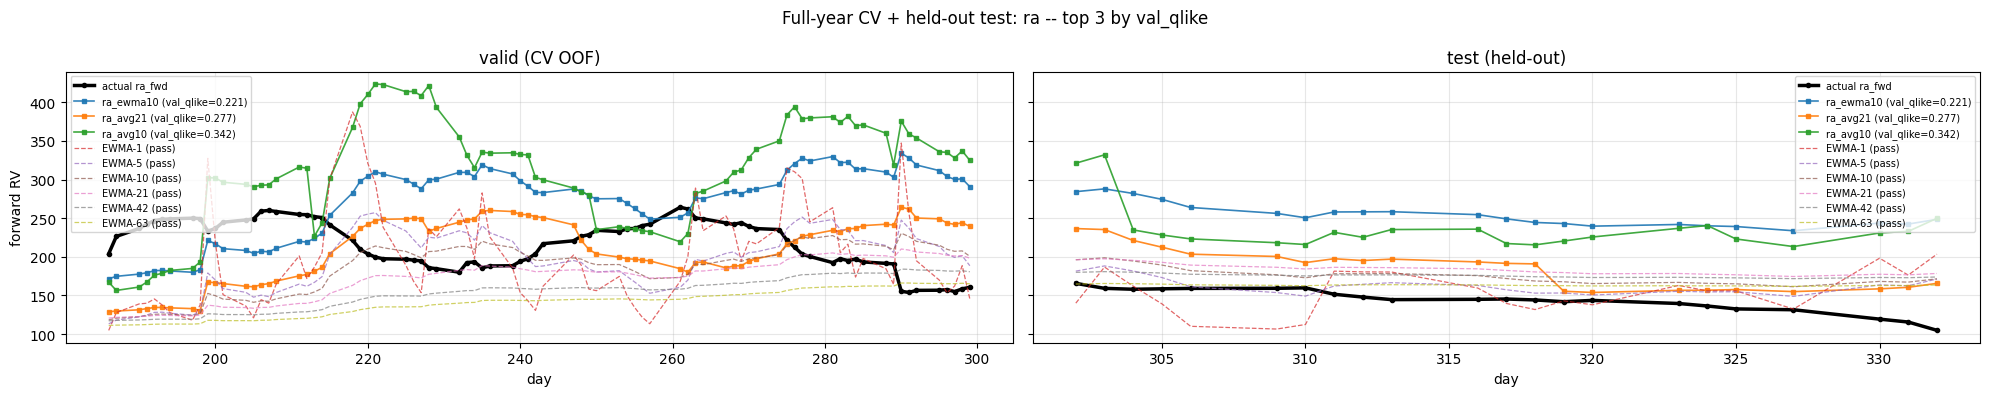


[rb] rb_ewma10
  features (1): rb_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma10=1

[rb] rb_avg10
  features (1): rb_avg10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_avg10=1

[rb] rb_ewma5
  features (1): rb_ewma5
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma5=1


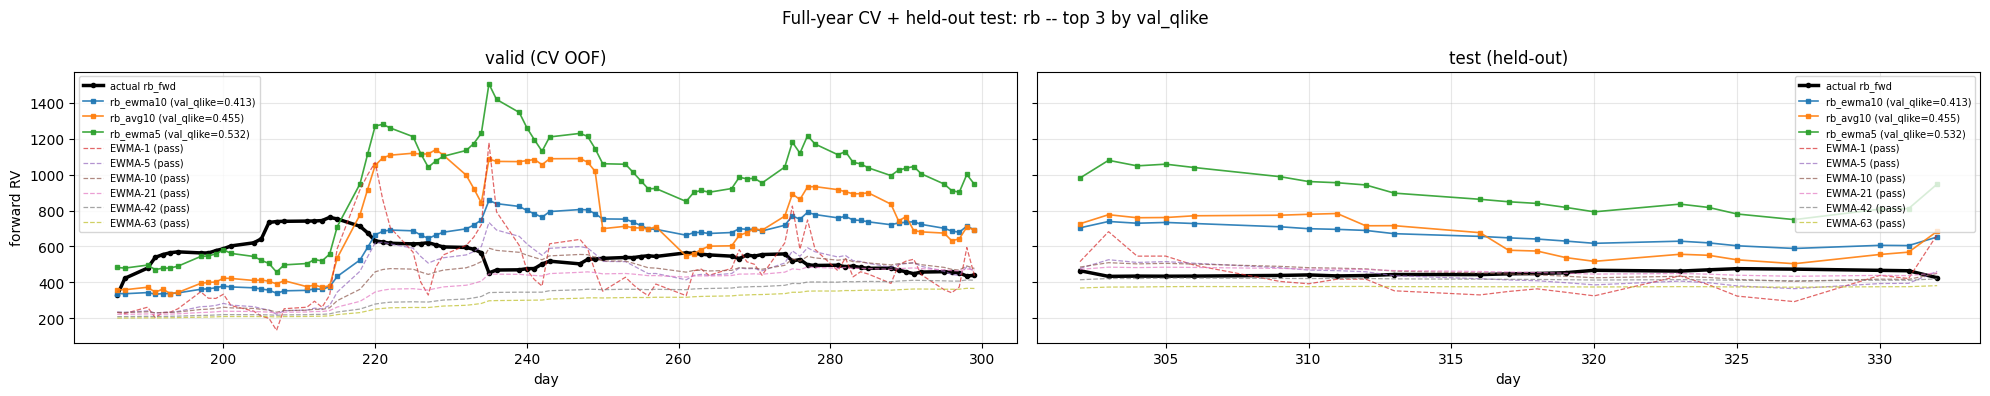


[rc] rc_ewma10
  features (1): rc_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma10=1

[rc] rc_avg10
  features (1): rc_avg10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_avg10=1

[rc] rc_avg21
  features (1): rc_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_avg21=1


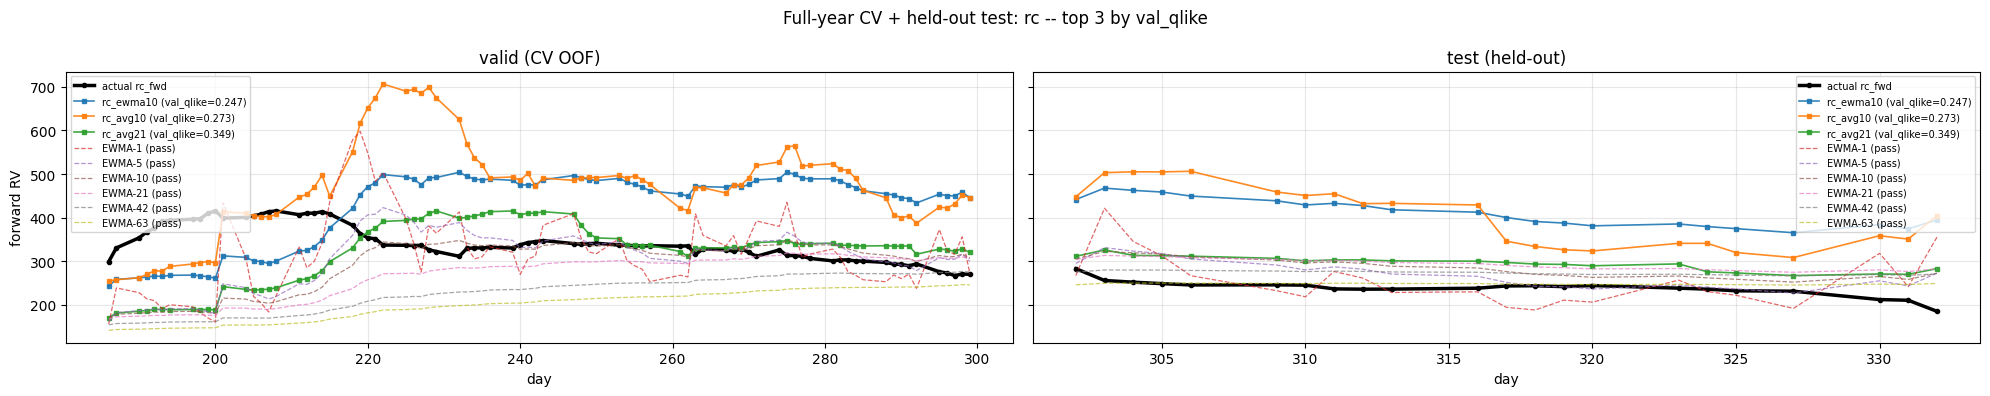


[rd] rd_ewma10
  features (1): rd_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_ewma10=1

[rd] rd_avg21
  features (1): rd_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_avg21=1

[rd] rd_avg10
  features (1): rd_avg10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rd_avg10=1


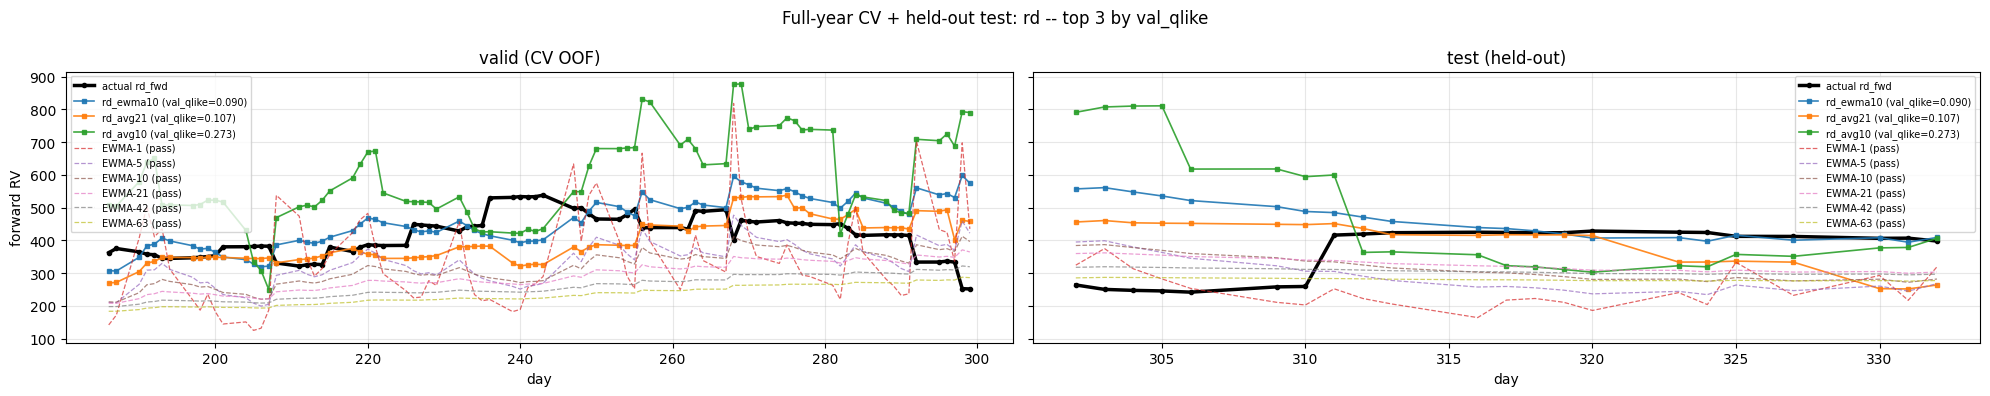


[re] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (5): log_re_ewma5, log_re_ewma10, log_re_ewma21, log_re_ewma42, log_re_ewma63
  intercept (log target scale, original feature scale): 16.5356
  coefficients (all, 5): log_re_ewma5=0.345783, log_re_ewma10=0.358943, log_re_ewma21=-1.94663, log_re_ewma42=-1.16962, log_re_ewma63=0.307306

[re] log HAR (LinReg)
  features (5): log_re_avg5, log_re_avg10, log_re_avg21, log_re_avg42, log_re_avg63
  intercept (log target scale, original feature scale): 11.548
  coefficients (all, 5): log_re_avg5=-0.0129058, log_re_avg10=-0.089773, log_re_avg21=0.324142, log_re_avg42=-0.324142, log_re_avg63=-1.06089

[re] log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (5): log_re_avg5, log_re_avg10, log_re_avg21, log_re_avg42, log_re_avg63
  intercept (log target scale, original feature scale): 11.2121
  coefficients (all, 5): log_re_avg5=-0.0135396, log_re_avg10=-0.0466572, log_re_avg21=0.246916, 

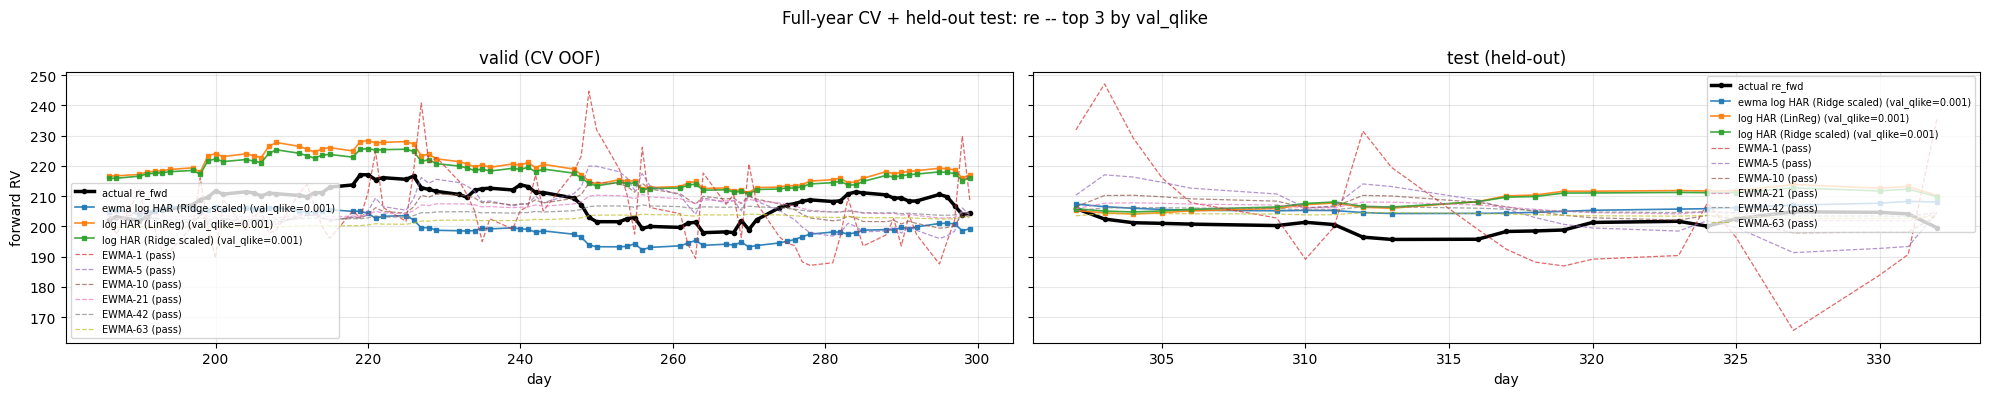


[rf] GARCH (pass)
  features (1): rf_garch_fwd
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_garch_fwd=1

[rf] rf_ewma10
  features (1): rf_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_ewma10=1

[rf] ewma HAR (LinReg)
  features (5): rf_ewma5, rf_ewma10, rf_ewma21, rf_ewma42, rf_ewma63
  intercept (target scale, original feature scale): -65.7433
  coefficients (all, 5): rf_ewma5=9.82501, rf_ewma10=-54.9146, rf_ewma21=165.18, rf_ewma42=-307.944, rf_ewma63=189.874


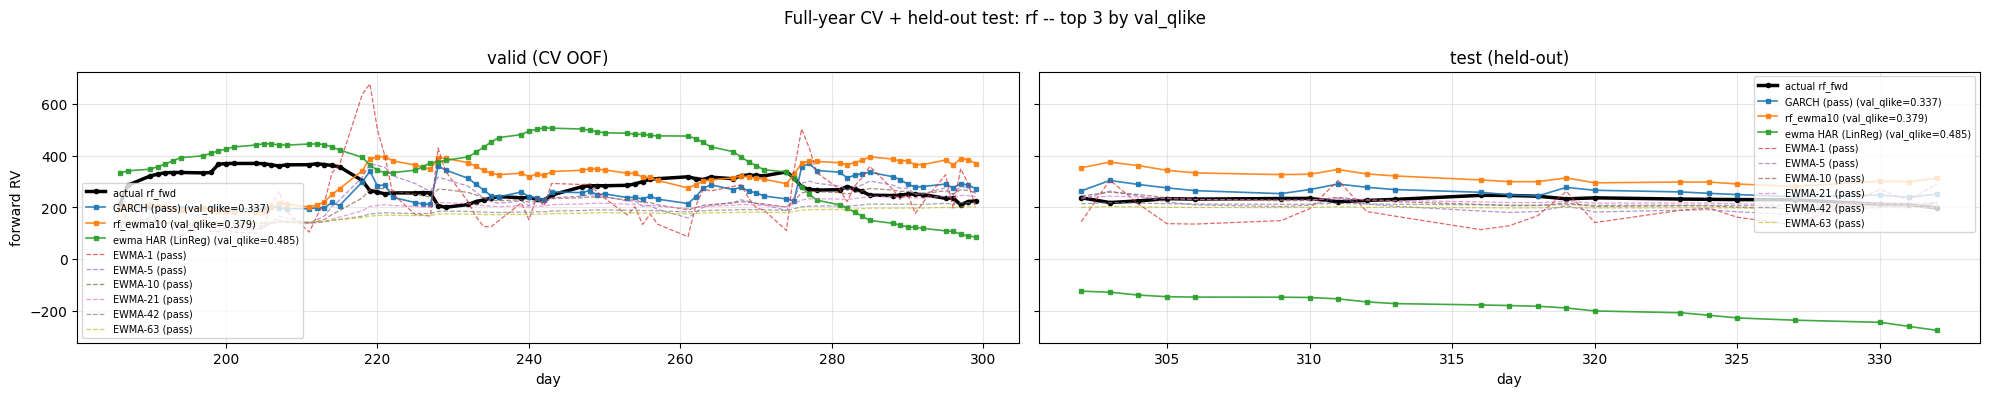

In [101]:
plot_top_models_last_fold(full_eval, top_k=3)


[ra] ra_ewma21
  features (1): ra_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_ewma21=1

[ra] ra_avg21
  features (1): ra_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): ra_avg21=1

[ra] log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (5): log_ra_avg5, log_ra_avg10, log_ra_avg21, log_ra_avg42, log_ra_avg63
  intercept (log target scale, original feature scale): 3.70329
  coefficients (all, 5): log_ra_avg5=0.0579415, log_ra_avg10=-0.0462775, log_ra_avg21=0.216303, log_ra_avg42=0.248368, log_ra_avg63=-0.166184


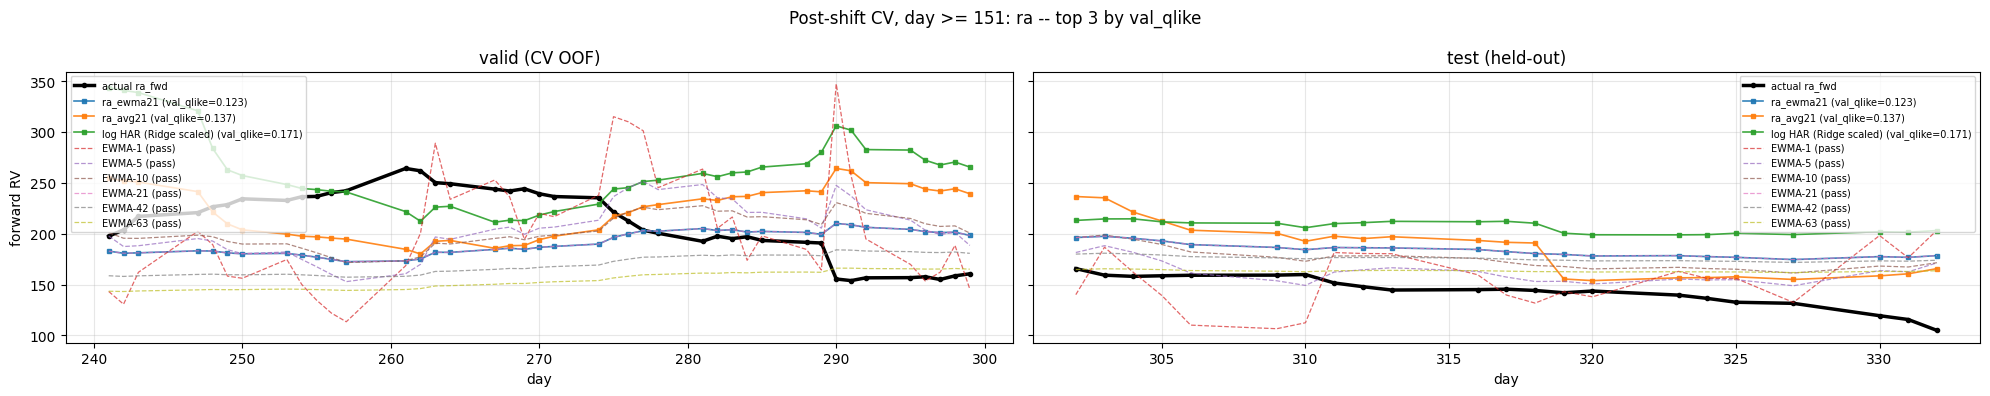


[rb] rb_ewma21
  features (1): rb_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_ewma21=1

[rb] rb_avg21
  features (1): rb_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_avg21=1

[rb] rb_avg42
  features (1): rb_avg42
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rb_avg42=1


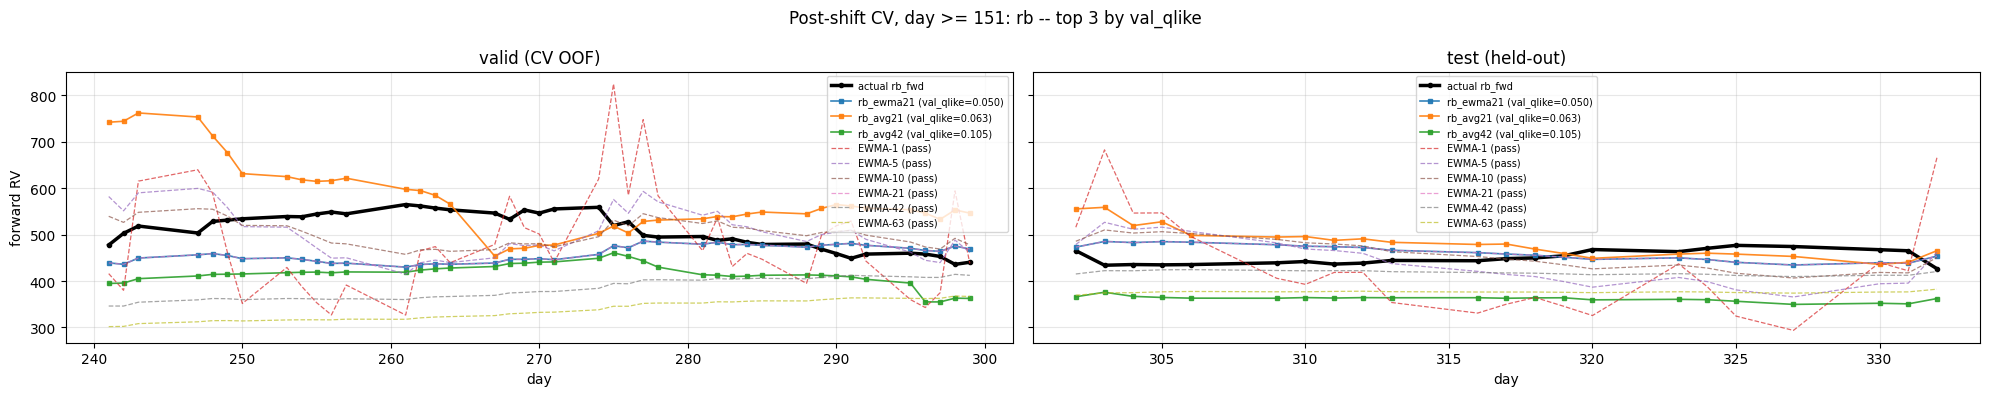


[rc] rc_ewma21
  features (1): rc_ewma21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_ewma21=1

[rc] rc_avg21
  features (1): rc_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_avg21=1

[rc] GARCH (pass)
  features (1): rc_garch_fwd
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rc_garch_fwd=1


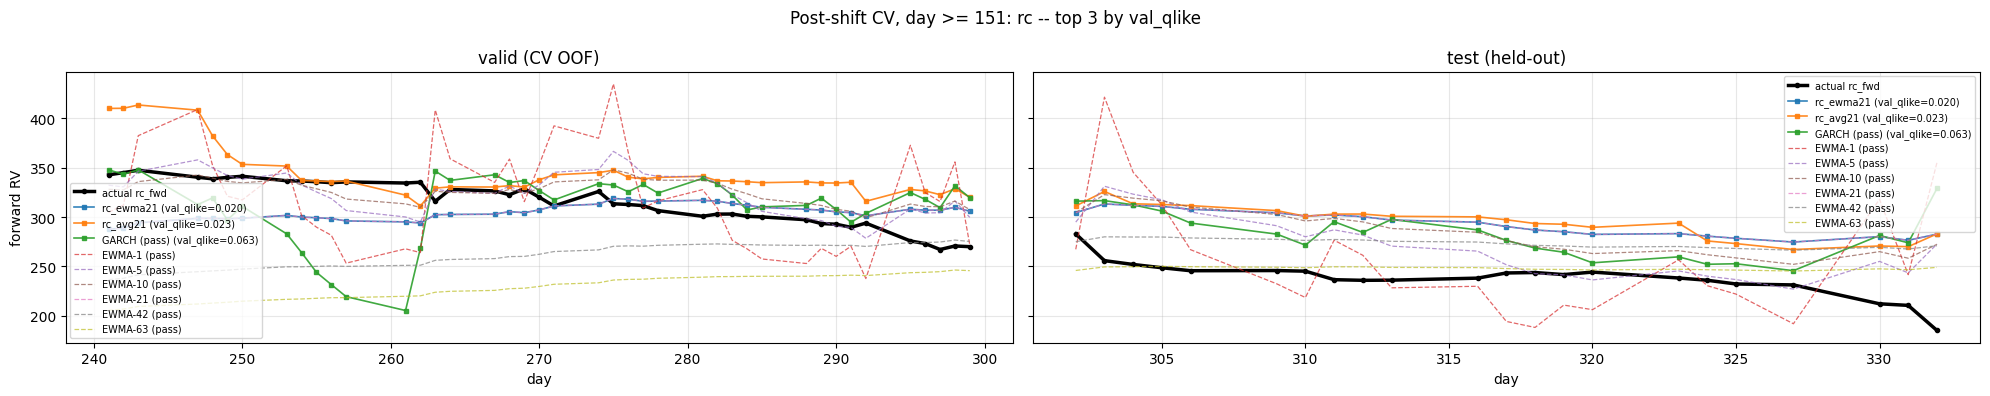


[rd] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (5): log_rd_ewma5, log_rd_ewma10, log_rd_ewma21, log_rd_ewma42, log_rd_ewma63
  intercept (log target scale, original feature scale): 0.0608646
  coefficients (all, 5): log_rd_ewma5=-0.324237, log_rd_ewma10=-0.0195505, log_rd_ewma21=0.263484, log_rd_ewma42=0.520886, log_rd_ewma63=0.669184

[rd] ewma HAR (Ridge scaled)
  best_params: ridge__alpha=10
  features (5): rd_ewma5, rd_ewma10, rd_ewma21, rd_ewma42, rd_ewma63
  intercept (target scale, original feature scale): -44.2126
  coefficients (all, 5): rd_ewma5=-0.476152, rd_ewma10=-0.0577618, rd_ewma21=0.412918, rd_ewma42=0.93191, rd_ewma63=1.3317

[rd] ewma log HAR (Ridge scaled)
  best_params: regressor__ridge__alpha=10
  features (5): log_rd_ewma5, log_rd_ewma10, log_rd_ewma21, log_rd_ewma42, log_rd_ewma63
  intercept (log target scale, original feature scale): 0.0608646
  coefficients (all, 5): log_rd_ewma5=-0.324237, log_rd_ewma10=-0.0195505, log

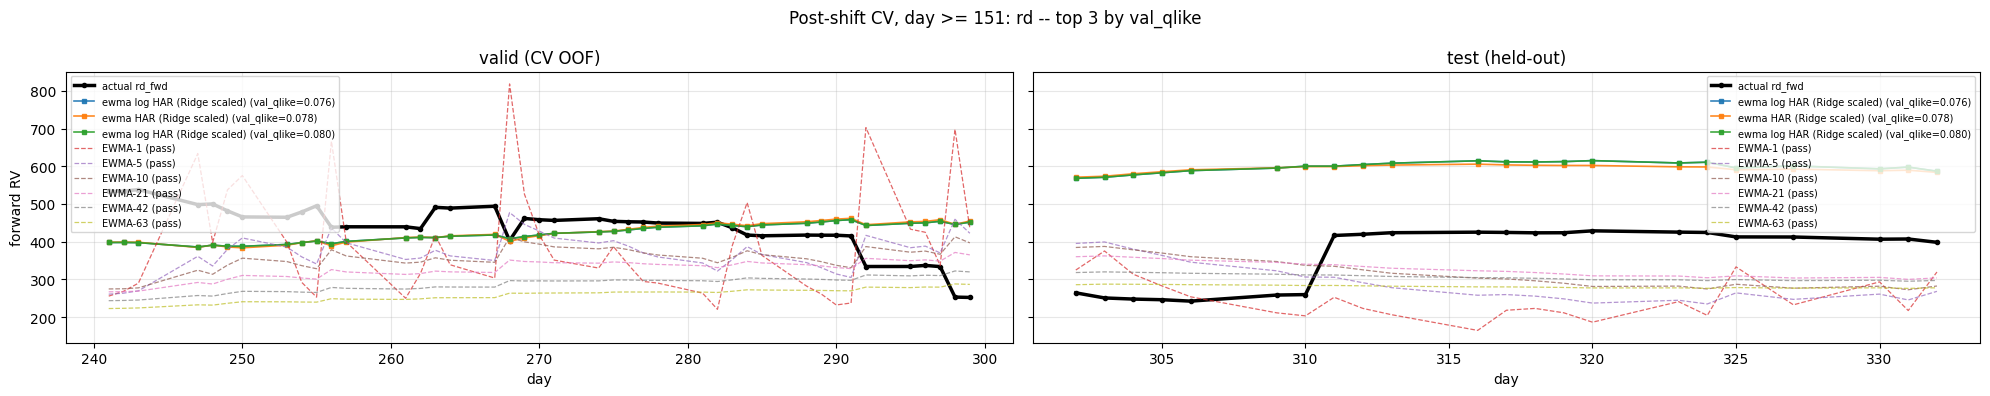


[re] HAR (LinReg)
  features (5): re_avg5, re_avg10, re_avg21, re_avg42, re_avg63
  intercept (target scale, original feature scale): 560.02
  coefficients (all, 5): re_avg5=0.0563399, re_avg10=-0.0203034, re_avg21=-0.487943, re_avg42=0.160123, re_avg63=-1.4087

[re] HAR (Ridge scaled)
  best_params: ridge__alpha=0.1
  features (5): re_avg5, re_avg10, re_avg21, re_avg42, re_avg63
  intercept (target scale, original feature scale): 559.227
  coefficients (all, 5): re_avg5=0.056164, re_avg10=-0.0202389, re_avg21=-0.484846, re_avg42=0.15514, re_avg63=-1.4029

[re] log HAR (LinReg)
  features (5): log_re_avg5, log_re_avg10, log_re_avg21, log_re_avg42, log_re_avg63
  intercept (log target scale, original feature scale): 14.4281
  coefficients (all, 5): log_re_avg5=0.0563742, log_re_avg10=-0.0253244, log_re_avg21=-0.475051, log_re_avg42=0.143371, log_re_avg63=-1.40413


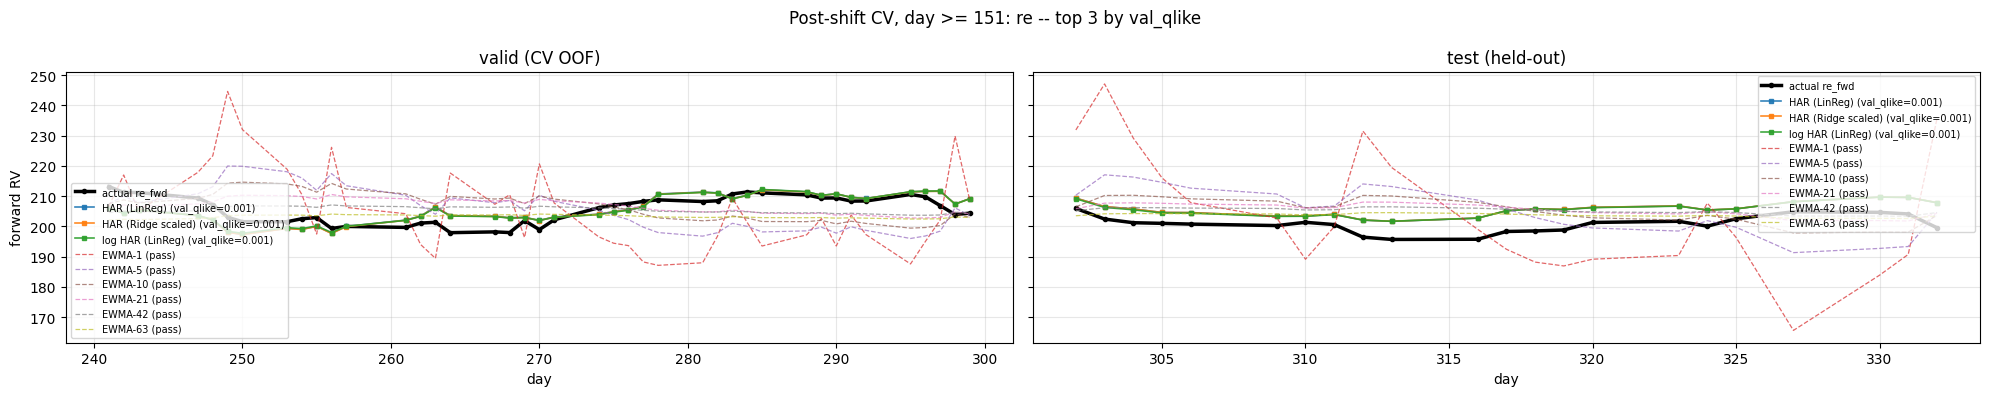


[rf] GARCH (pass)
  features (1): rf_garch_fwd
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_garch_fwd=1

[rf] rf_ewma10
  features (1): rf_ewma10
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_ewma10=1

[rf] rf_avg21
  features (1): rf_avg21
  intercept (target scale, pass-through feature scale): 0
  coefficients (all, 1): rf_avg21=1


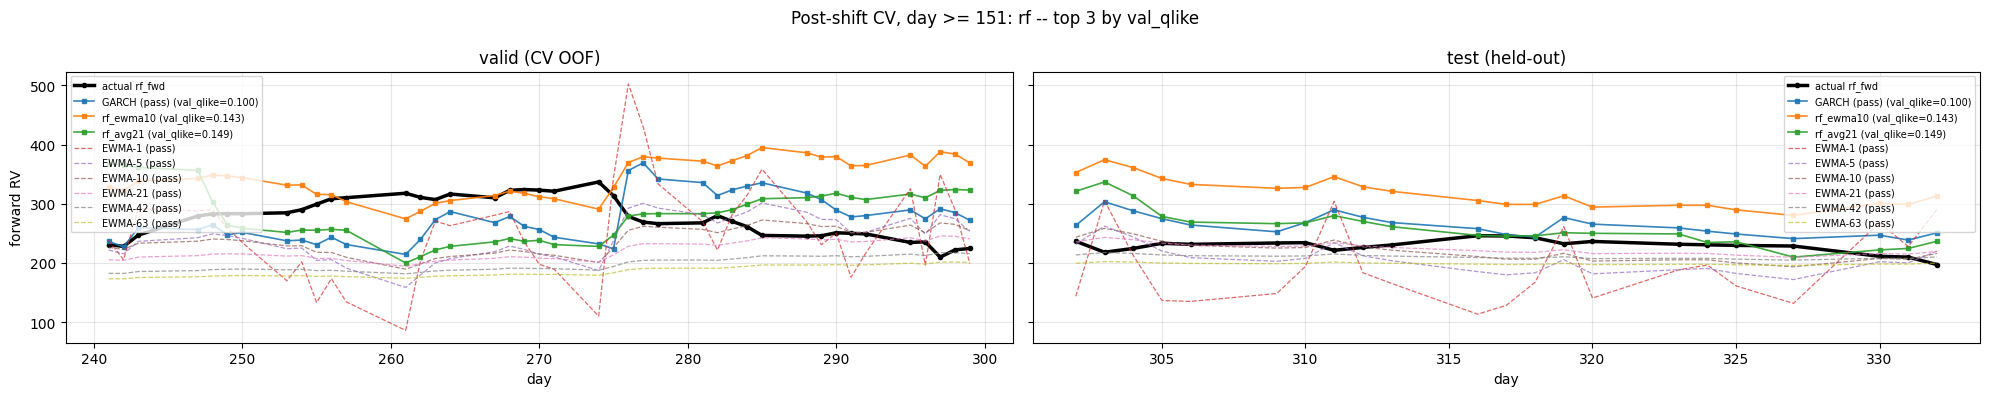

In [102]:
plot_top_models_last_fold(post_shift_eval, top_k=3)

In [103]:
def per_fold_breakdown(
    eval_result,
    top_k=3,
    ewma_windows=(1, 5, 11, 21),
    rank_metric="val_qlike",
    primary_loss="qlike",
    horizon=21,
):
    """Per stock: show pre-test CV fold losses and held-out test losses for
    the top-k tuned models plus EWMA pass-through baselines."""
    report = eval_result["report"]
    X_eval = eval_result["X"]
    cv = eval_result["cv"]
    label = eval_result["label"]
    model_results = eval_result.get("model_results", {})
    test_start_day = eval_result.get("test_start_day")
    test_end_day = eval_result.get("test_end_day")
    purge = eval_result.get("purge", horizon)
    train_span = eval_result.get("train_span")
    sort_std = f"{rank_metric}_std"
    sort_cols = [rank_metric] + ([sort_std] if sort_std in report.columns else [])

    print(label)
    for s in returns:
        spec_lookup = {
            name: (model, feats, grid)
            for name, model, feats, grid in model_specs_for_stock(s)
        }
        top = report.filter(pl.col("stock") == s).sort(sort_cols).head(top_k)
        rows = []
        target_col = f"{s}_fwd"

        # Top-k tuned models: read the stored pre-test CV folds and held-out
        # test metrics from run_model_report.
        for row in top.iter_rows(named=True):
            name = row["model"]
            if name not in spec_lookup:
                continue
            model, feats, grid = spec_lookup[name]
            r = model_results.get((s, name))
            if r is None:
                r = evaluate_model_with_test(
                    X_eval,
                    y,
                    model,
                    feats,
                    target_col,
                    param_grid=grid,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                    test_start_day=test_start_day,
                    test_end_day=test_end_day,
                    purge=purge,
                    train_span=train_span,
                )
            qfolds = np.asarray(r["qlike_fold_errors"], dtype=float)
            rfolds = np.asarray(r["rmse_fold_errors"], dtype=float)
            rows.append(
                {
                    "kind": "top",
                    "model": name,
                    "qlike_folds": [round(float(v), 4) for v in qfolds],
                    "cv_qlike_mean": round(float(qfolds.mean()), 4),
                    "cv_qlike_std": round(float(qfolds.std()), 4),
                    "rmse_folds": [round(float(v), 2) for v in rfolds],
                    "cv_rmse_mean": round(float(rfolds.mean()), 2),
                    "cv_rmse_std": round(float(rfolds.std()), 2),
                    "test_qlike": round(float(r.get("test_qlike", np.nan)), 4),
                    "test_rmse": round(float(r.get("test_rmse", np.nan)), 2),
                }
            )

        # EWMA pass-through baselines: prediction = feature at t, no fit.
        for w in ewma_windows:
            feat = f"{s}_ewma{w}"
            if feat not in X_eval.columns:
                continue
            baseline_name = f"EWMA-{w} (pass)"
            r = model_results.get((s, baseline_name))
            if r is None:
                r = evaluate_model_with_test(
                    X_eval,
                    y,
                    PassthroughRegressor(),
                    [feat],
                    target_col,
                    cv=cv,
                    horizon=horizon,
                    primary_loss=primary_loss,
                    test_start_day=test_start_day,
                    test_end_day=test_end_day,
                    purge=purge,
                    train_span=train_span,
                )
            qfolds = np.asarray(r["qlike_fold_errors"], dtype=float)
            rfolds = np.asarray(r["rmse_fold_errors"], dtype=float)
            rows.append(
                {
                    "kind": "ewma",
                    "model": baseline_name,
                    "qlike_folds": [round(float(v), 4) for v in qfolds],
                    "cv_qlike_mean": round(float(qfolds.mean()), 4),
                    "cv_qlike_std": round(float(qfolds.std()), 4),
                    "rmse_folds": [round(float(v), 2) for v in rfolds],
                    "cv_rmse_mean": round(float(rfolds.mean()), 2),
                    "cv_rmse_std": round(float(rfolds.std()), 2),
                    "test_qlike": round(float(r.get("test_qlike", np.nan)), 4),
                    "test_rmse": round(float(r.get("test_rmse", np.nan)), 2),
                }
            )

        if not rows:
            continue
        out = pl.DataFrame(rows)
        print(f"\n--- target: {target_col} ---")
        with pl.Config(tbl_cols=12, tbl_rows=20, fmt_str_lengths=160):
            display(out)

In [104]:
per_fold_breakdown(full_eval, top_k=3, ewma_windows=tuple(windows))

Full-year CV + held-out test

--- target: ra_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""ra_ewma10""",[0.2207],0.2207,0.0,[90.2],90.2,0.0,0.4704,111.17
"""top""","""ra_avg21""",[0.277],0.277,0.0,[67.92],67.92,0.0,0.1198,45.51
"""top""","""ra_avg10""",[0.3421],0.3421,0.0,[130.66],130.66,0.0,0.3794,97.67
"""ewma""","""EWMA-1 (pass)""",[0.3908],0.3908,0.0,[78.71],78.71,0.0,0.1304,39.31
"""ewma""","""EWMA-5 (pass)""",[0.331],0.331,0.0,[66.81],66.81,0.0,0.0492,24.82
"""ewma""","""EWMA-10 (pass)""",[0.3466],0.3466,0.0,[65.85],65.85,0.0,0.0822,33.67
"""ewma""","""EWMA-21 (pass)""",[0.4105],0.4105,0.0,[69.31],69.31,0.0,0.1165,41.55
"""ewma""","""EWMA-42 (pass)""",[0.5801],0.5801,0.0,[78.89],78.89,0.0,0.0872,34.53
"""ewma""","""EWMA-63 (pass)""",[0.8002],0.8002,0.0,[88.15],88.15,0.0,0.0502,24.59



--- target: rb_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rb_ewma10""",[0.4131],0.4131,0.0,[237.49],237.49,0.0,0.2424,221.16
"""top""","""rb_avg10""",[0.4547],0.4547,0.0,[343.99],343.99,0.0,0.2435,234.11
"""top""","""rb_ewma5""",[0.5324],0.5324,0.0,[493.41],493.41,0.0,0.6399,465.25
"""ewma""","""EWMA-1 (pass)""",[1.2314],1.2314,0.0,[244.36],244.36,0.0,0.1433,114.8
"""ewma""","""EWMA-5 (pass)""",[0.9616],0.9616,0.0,[212.95],212.95,0.0,0.0416,61.7
"""ewma""","""EWMA-10 (pass)""",[1.0468],1.0468,0.0,[218.55],218.55,0.0,0.0199,45.94
"""ewma""","""EWMA-21 (pass)""",[1.3424],1.3424,0.0,[240.74],240.74,0.0,0.0094,31.73
"""ewma""","""EWMA-42 (pass)""",[1.8988],1.8988,0.0,[275.03],275.03,0.0,0.0161,37.86
"""ewma""","""EWMA-63 (pass)""",[2.3956],2.3956,0.0,[298.09],298.09,0.0,0.0771,76.17



--- target: rc_fwd ---


...

kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rd_ewma10""",[0.0895],0.0895,0.0,[100.9],100.9,0.0,0.2314,159.3
"""top""","""rd_avg21""",[0.1068],0.1068,0.0,[89.05],89.05,0.0,0.2543,131.19
"""top""","""rd_avg10""",[0.2734],0.2734,0.0,[225.31],225.31,0.0,0.4672,280.56
"""ewma""","""EWMA-1 (pass)""",[0.9205],0.9205,0.0,[180.21],180.21,0.0,0.9486,161.55
"""ewma""","""EWMA-5 (pass)""",[0.336],0.336,0.0,[122.77],122.77,0.0,0.5267,146.33
"""ewma""","""EWMA-10 (pass)""",[0.333],0.333,0.0,[125.18],125.18,0.0,0.3011,122.65
"""ewma""","""EWMA-21 (pass)""",[0.4771],0.4771,0.0,[143.8],143.8,0.0,0.1954,103.05
"""ewma""","""EWMA-42 (pass)""",[0.7976],0.7976,0.0,[171.46],171.46,0.0,0.2133,103.2
"""ewma""","""EWMA-63 (pass)""",[1.1913],1.1913,0.0,[193.73],193.73,0.0,0.3089,116.78



--- target: re_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""ewma log HAR (Ridge scaled)""",[0.0043],0.0043,0.0,[9.29],9.29,0.0,0.0014,5.45
"""top""","""log HAR (LinReg)""",[0.0055],0.0055,0.0,[11.37],11.37,0.0,0.0036,8.88
"""top""","""log HAR (Ridge scaled)""",[0.0044],0.0044,0.0,[10.16],10.16,0.0,0.0035,8.63
"""ewma""","""EWMA-1 (pass)""",[0.0084],0.0084,0.0,[13.53],13.53,0.0,0.0202,21.09
"""ewma""","""EWMA-5 (pass)""",[0.0038],0.0038,0.0,[8.95],8.95,0.0,0.0049,10.24
"""ewma""","""EWMA-10 (pass)""",[0.0029],0.0029,0.0,[7.9],7.9,0.0,0.0027,7.53
"""ewma""","""EWMA-21 (pass)""",[0.0022],0.0022,0.0,[6.88],6.88,0.0,0.002,6.44
"""ewma""","""EWMA-42 (pass)""",[0.0023],0.0023,0.0,[7.02],7.02,0.0,0.0015,5.66
"""ewma""","""EWMA-63 (pass)""",[0.0035],0.0035,0.0,[8.47],8.47,0.0,0.0009,4.37



--- target: rf_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""GARCH (pass)""",[0.3373],0.3373,0.0,[94.93],94.93,0.0,0.0447,39.8
"""top""","""rf_ewma10""",[0.3788],0.3788,0.0,[115.81],115.81,0.0,0.1854,93.99
"""top""","""ewma HAR (LinReg)""",[0.485],0.485,0.0,[133.97],133.97,0.0,5.2391e10,416.0
"""ewma""","""EWMA-1 (pass)""",[1.7101],1.7101,0.0,[148.5],148.5,0.0,0.4659,77.8
"""ewma""","""EWMA-5 (pass)""",[1.0843],1.0843,0.0,[122.32],122.32,0.0,0.0723,37.3
"""ewma""","""EWMA-10 (pass)""",[1.0319],1.0319,0.0,[119.07],119.07,0.0,0.0235,23.45
"""ewma""","""EWMA-21 (pass)""",[1.0898],1.0898,0.0,[123.1],123.1,0.0,0.0096,15.44
"""ewma""","""EWMA-42 (pass)""",[1.1425],1.1425,0.0,[129.5],129.5,0.0,0.0212,21.95
"""ewma""","""EWMA-63 (pass)""",[1.1738],1.1738,0.0,[132.78],132.78,0.0,0.05,32.22


In [83]:
per_fold_breakdown(post_shift_eval, top_k=3, ewma_windows=tuple(windows))

Post-shift CV, day >= 151

--- target: ra_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""ra_ewma21""",[0.1231],0.1231,0.0,[47.15],47.15,0.0,0.1165,41.55
"""top""","""ra_avg21""",[0.1365],0.1365,0.0,[57.28],57.28,0.0,0.1198,45.51
"""top""","""log HAR (Ridge scaled)""",[3.2556],3.2556,0.0,[1776.05],1776.05,0.0,0.446,105.99
"""ewma""","""EWMA-1 (pass)""",[0.2564],0.2564,0.0,[66.45],66.45,0.0,0.1304,39.31
"""ewma""","""EWMA-5 (pass)""",[0.1416],0.1416,0.0,[51.58],51.58,0.0,0.0492,24.82
"""ewma""","""EWMA-10 (pass)""",[0.1105],0.1105,0.0,[46.47],46.47,0.0,0.0822,33.67
"""ewma""","""EWMA-21 (pass)""",[0.1231],0.1231,0.0,[47.15],47.15,0.0,0.1165,41.55
"""ewma""","""EWMA-42 (pass)""",[0.226],0.226,0.0,[58.01],58.01,0.0,0.0872,34.53
"""ewma""","""EWMA-63 (pass)""",[0.3756],0.3756,0.0,[69.14],69.14,0.0,0.0502,24.59



--- target: rb_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""rb_ewma21""",[0.05],0.05,0.0,[72.53],72.53,0.0,0.0094,31.73
"""top""","""rb_avg21""",[0.0625],0.0625,0.0,[109.43],109.43,0.0,0.0225,53.55
"""top""","""rb_avg42""",[0.1045],0.1045,0.0,[98.46],98.46,0.0,0.118,90.83
"""ewma""","""EWMA-1 (pass)""",[0.1399],0.1399,0.0,[120.23],120.23,0.0,0.1433,114.8
"""ewma""","""EWMA-5 (pass)""",[0.0395],0.0395,0.0,[68.73],68.73,0.0,0.0416,61.7
"""ewma""","""EWMA-10 (pass)""",[0.0223],0.0223,0.0,[51.96],51.96,0.0,0.0199,45.94
"""ewma""","""EWMA-21 (pass)""",[0.05],0.05,0.0,[72.53],72.53,0.0,0.0094,31.73
"""ewma""","""EWMA-42 (pass)""",[0.248],0.248,0.0,[137.96],137.96,0.0,0.0161,37.86
"""ewma""","""EWMA-63 (pass)""",[0.5274],0.5274,0.0,[180.81],180.81,0.0,0.0771,76.17



--- target: rc_fwd ---


...

kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""log HAR (Ridge scaled)""",[0.0805],0.0805,0.0,[83.17],83.17,0.0,0.4217,242.09
"""top""","""HAR (Ridge scaled)""",[0.0821],0.0821,0.0,[84.2],84.2,0.0,0.4148,239.08
"""top""","""log HAR (Ridge scaled)""",[0.0805],0.0805,0.0,[83.17],83.17,0.0,0.4217,242.09
"""ewma""","""EWMA-1 (pass)""",[0.5009],0.5009,0.0,[183.97],183.97,0.0,0.9486,161.55
"""ewma""","""EWMA-5 (pass)""",[0.2492],0.2492,0.0,[119.13],119.13,0.0,0.5267,146.33
"""ewma""","""EWMA-10 (pass)""",[0.2519],0.2519,0.0,[120.7],120.7,0.0,0.3011,122.65
"""ewma""","""EWMA-21 (pass)""",[0.3706],0.3706,0.0,[139.92],139.92,0.0,0.1954,103.05
"""ewma""","""EWMA-42 (pass)""",[0.6723],0.6723,0.0,[171.64],171.64,0.0,0.2133,103.2
"""ewma""","""EWMA-63 (pass)""",[1.0419],1.0419,0.0,[196.59],196.59,0.0,0.3089,116.78



--- target: re_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""HAR (LinReg)""",[0.0613],0.0613,0.0,[42.79],42.79,0.0,0.0116,16.41
"""top""","""HAR (Ridge scaled)""",[0.0034],0.0034,0.0,[8.23],8.23,0.0,0.0027,7.54
"""top""","""log HAR (LinReg)""",[0.0655],0.0655,0.0,[44.64],44.64,0.0,0.0109,15.85
"""ewma""","""EWMA-1 (pass)""",[0.0109],0.0109,0.0,[15.6],15.6,0.0,0.0202,21.09
"""ewma""","""EWMA-5 (pass)""",[0.0049],0.0049,0.0,[10.21],10.21,0.0,0.0049,10.24
"""ewma""","""EWMA-10 (pass)""",[0.0032],0.0032,0.0,[8.3],8.3,0.0,0.0027,7.53
"""ewma""","""EWMA-21 (pass)""",[0.0019],0.0019,0.0,[6.46],6.46,0.0,0.002,6.44
"""ewma""","""EWMA-42 (pass)""",[0.0013],0.0013,0.0,[5.32],5.32,0.0,0.0015,5.66
"""ewma""","""EWMA-63 (pass)""",[0.0015],0.0015,0.0,[5.51],5.51,0.0,0.0009,4.37



--- target: rf_fwd ---


kind,model,qlike_folds,cv_qlike_mean,cv_qlike_std,rmse_folds,cv_rmse_mean,cv_rmse_std,test_qlike,test_rmse
str,str,list[f64],f64,f64,list[f64],f64,f64,f64,f64
"""top""","""GARCH (pass)""",[0.1],0.1,0.0,[60.67],60.67,0.0,0.0447,39.8
"""top""","""rf_ewma10""",[0.143],0.143,0.0,[92.11],92.11,0.0,0.1854,93.99
"""top""","""rf_avg21""",[0.1494],0.1494,0.0,[74.93],74.93,0.0,0.0493,44.89
"""ewma""","""EWMA-1 (pass)""",[0.6966],0.6966,0.0,[100.01],100.01,0.0,0.4659,77.8
"""ewma""","""EWMA-5 (pass)""",[0.2236],0.2236,0.0,[72.01],72.01,0.0,0.0723,37.3
"""ewma""","""EWMA-10 (pass)""",[0.1714],0.1714,0.0,[66.23],66.23,0.0,0.0235,23.45
"""ewma""","""EWMA-21 (pass)""",[0.2169],0.2169,0.0,[72.82],72.82,0.0,0.0096,15.44
"""ewma""","""EWMA-42 (pass)""",[0.3863],0.3863,0.0,[89.89],89.89,0.0,0.0212,21.95
"""ewma""","""EWMA-63 (pass)""",[0.5191],0.5191,0.0,[99.6],99.6,0.0,0.05,32.22
